# Mutual Fund Performance Analytics

## Internship Project

### Objectives

This notebook evaluates the historical performance of mutual funds using various financial performance metrics.

### Metrics Covered

- Daily Returns
- CAGR
- Sharpe Ratio
- Sortino Ratio
- Alpha
- Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

In [14]:
#Load the Data Files
# NAV History
nav = pd.read_csv(r"D:\mutual-fund-analysis\data\processed\nav_history_cleaned.csv")

# Scheme Performance
scheme = pd.read_csv(r"D:\mutual-fund-analysis\data\processed\cleaned_scheme_performance.csv")

# Benchmark
benchmark = pd.read_csv(r"D:\mutual-fund-analysis\data\raw\benchmark_indices.csv")

# Fund Master
fund = pd.read_csv(r"D:\mutual-fund-analysis\data\raw\fund_master.csv")

In [4]:
#Check the dataset
print("NAV History :", nav.shape)
print("Scheme Performance :", scheme.shape)
print("Benchmark :", benchmark.shape)
print("Fund Master :", fund.shape)

NAV History : (46000, 3)
Scheme Performance : (42, 19)
Benchmark : (8050, 3)
Fund Master : (40, 15)


In [5]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
#Check Columns
print(nav.columns)

print()

print(scheme.columns)

print()

print(benchmark.columns)

print()

print(fund.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

Index(['date', 'index_name', 'close_value'], dtype='object')

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')


# Task 1: Daily Return Analysis

## Objective

Compute the daily return for each mutual fund scheme using historical NAV data.

### Formula

Daily Return = (Today's NAV / Previous Day's NAV) - 1

This metric measures the percentage change in NAV from one trading day to the next and forms the foundation for calculating financial performance metrics such as Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown.

In [7]:
#Sort the NAV data by Scheme code and date 
# Convert date to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort data by Scheme and Date
nav = nav.sort_values(["amfi_code", "date"])

# Check
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [8]:
#Compute Daily Returns 
# Daily Return Calculation
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [9]:
#Missing Values Check
print("Missing Daily Returns:", nav["daily_return"].isna().sum())

Missing Daily Returns: 40


In [10]:
#Remove Missing Values
daily_returns = nav.dropna(subset=["daily_return"]).copy()

print(daily_returns.shape)

(45960, 4)


In [11]:
#Summary Satistics of Daily RTeturns 
daily_returns["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

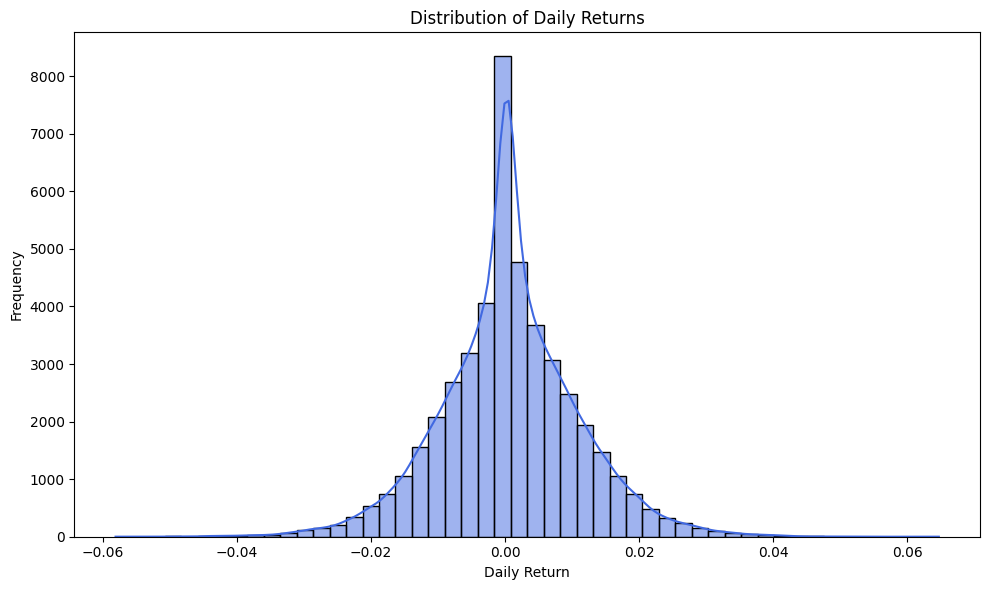

In [12]:
#Plot Distribution (Histogram) of Daily Returns
fig, ax = plt.subplots(figsize=(10,6))

sns.histplot(
    daily_returns["daily_return"],
    bins=50,
    kde=True,
    color="royalblue",
    ax=ax
)

ax.set_title("Distribution of Daily Returns")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Frequency")

fig.tight_layout()

fig.savefig(
    r"D:\mutual-fund-analysis\reports\daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)

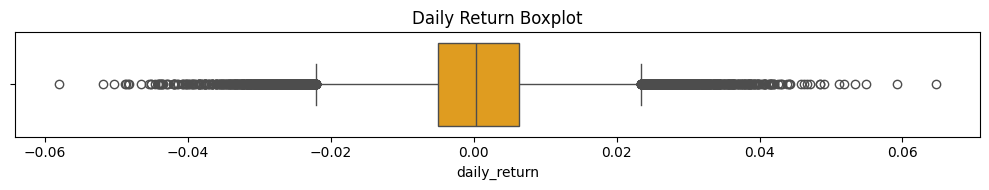

In [14]:
#BoxPlot of Daily Returns
fig, ax = plt.subplots(figsize=(10,2))

sns.boxplot(
    x=daily_returns["daily_return"],
    color="orange",
    ax=ax
)

ax.set_title("Daily Return Boxplot")

fig.tight_layout()

fig.savefig(
    r"D:\mutual-fund-analysis\reports\daily_return_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)


## Observation

- Most daily returns are concentrated around 0%, indicating relatively stable day-to-day movements.
- The distribution is approximately centered near zero with a small number of positive and negative outliers.
- Extreme values correspond to periods of high market volatility.
- The calculated daily returns will be used in subsequent analyses including Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown.

In [15]:
daily_returns.shape

(45960, 4)

In [16]:
daily_returns["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

# Task 2: Compound Annual Growth Rate (CAGR)

## Objective

Calculate the Compound Annual Growth Rate (CAGR) for each mutual fund using historical NAV values.

### Formula

CAGR = (Ending NAV / Beginning NAV)^(1 / Years) − 1

The CAGR measures the annualized growth rate of an investment over a specified period.

In [17]:
#Helper Function to Calculate
def calculate_cagr(df, years):
    """
    Calculate CAGR for each AMFI scheme.
    """

    result = []

    latest_date = df["date"].max()

    start_date = latest_date - pd.DateOffset(years=years)

    for amfi, group in df.groupby("amfi_code"):

        group = group.sort_values("date")

        recent = group[group["date"] >= start_date]

        if len(recent) < 2:
            continue

        start_nav = recent.iloc[0]["nav"]
        end_nav = recent.iloc[-1]["nav"]

        cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

        result.append({
            "amfi_code": amfi,
            f"CAGR_{years}Y": cagr
        })

    return pd.DataFrame(result)

In [18]:
# Calculate CAGR
cagr_1 = calculate_cagr(nav, 1)
cagr_3 = calculate_cagr(nav, 3)
cagr_5 = calculate_cagr(nav, 5)

In [19]:
#Merge All CARG Results
cagr = cagr_1.merge(cagr_3, on="amfi_code", how="outer")

cagr = cagr.merge(
    cagr_5,
    on="amfi_code",
    how="outer"
)

cagr.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.224271,1.292649,2.316843
1,100025,3.704969,3.916390,3.912653
2,100033,53.232396,32.442459,26.074068
3,101206,47.924120,28.967695,20.442730
4,101207,-23.986032,-4.152381,6.953336


In [20]:
#Add Scheme Name
cagr = cagr.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

cagr.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name
0,100016,-2.224271,1.292649,2.316843,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,3.704969,3.916390,3.912653,HDFC Short Term Debt Fund - Regular - Growth
2,100033,53.232396,32.442459,26.074068,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,47.924120,28.967695,20.442730,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-23.986032,-4.152381,6.953336,ABSL Small Cap Fund - Regular - Growth


In [21]:
#Rearrange Columns
cagr = cagr[
    [
        "amfi_code",
        "scheme_name",
        "CAGR_1Y",
        "CAGR_3Y",
        "CAGR_5Y"
    ]
]

cagr.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.224271,1.292649,2.316843
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.704969,3.916390,3.912653
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,26.074068
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,20.442730
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.152381,6.953336


In [22]:
#Save the CAGR results to CSV
cagr.to_csv(
    r"D:\mutual-fund-analysis/data/processed/cagr_comparison.csv",
    index=False
)

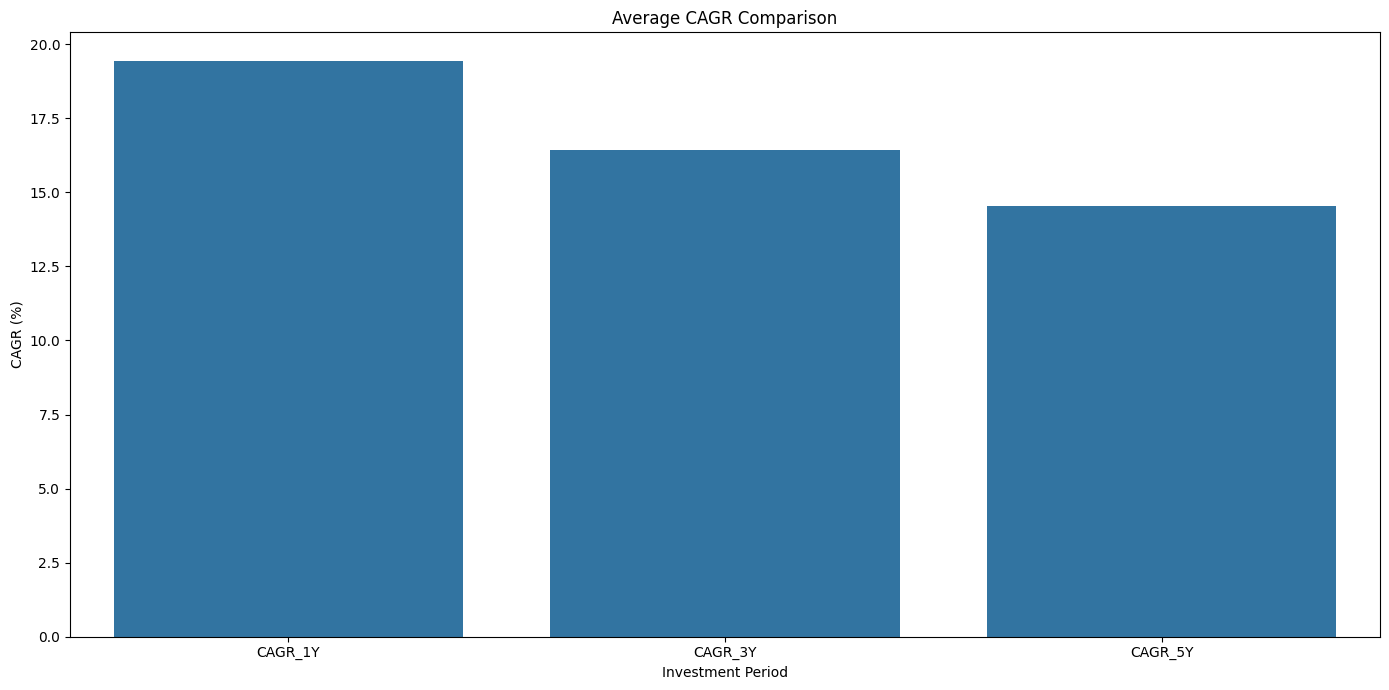

In [23]:
#Plot Comparison Chart 
fig, ax = plt.subplots(figsize=(14,7))

cagr_plot = cagr.melt(
    id_vars="scheme_name",
    value_vars=[
        "CAGR_1Y",
        "CAGR_3Y",
        "CAGR_5Y"
    ]
)

sns.barplot(
    data=cagr_plot,
    x="variable",
    y="value",
    errorbar=None,
    ax=ax
)

ax.set_title("Average CAGR Comparison")

ax.set_xlabel("Investment Period")

ax.set_ylabel("CAGR (%)")

fig.tight_layout()

fig.savefig(
    "../reports/cagr_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)

## Observation

- CAGR provides a standardized measure of annualized growth across different investment horizons.
- Longer investment periods generally provide a more stable estimate of fund performance.
- CAGR values will be used as one of the indicators when evaluating long-term fund performance.

# Task 3: Sharpe Ratio Analysis

## Objective

Evaluate the risk-adjusted performance of each mutual fund using the Sharpe Ratio.

### Formula

Sharpe Ratio = (Annual Return − Risk Free Rate) / Annualized Standard Deviation

Where:

- Risk Free Rate = 6.5%
- Trading Days = 252

Higher Sharpe Ratio indicates better risk-adjusted returns.

In [24]:
# Annualized Return
annual_return = (
    daily_returns
    .groupby("amfi_code")["daily_return"]
    .mean()
    * 252
)

annual_return.head()

amfi_code
100016    0.035683
100025    0.042854
100033    0.272111
101206    0.214647
101207    0.106962
Name: daily_return, dtype: float64

In [25]:
#Anualized Standard Deviation (Volatility)
annual_std = (
    daily_returns
    .groupby("amfi_code")["daily_return"]
    .std()
    * np.sqrt(252)
)

annual_std.head()

amfi_code
100016    0.145481
100025    0.039052
100033    0.189367
101206    0.145682
101207    0.257973
Name: daily_return, dtype: float64

In [26]:
risk_free_rate = 0.065

In [27]:
#Compute Sharp Ratio
sharpe = pd.DataFrame()

sharpe["Annual_Return"] = annual_return

sharpe["Annual_Std"] = annual_std

sharpe["Sharpe_Ratio"] = (
    (sharpe["Annual_Return"] - risk_free_rate)
    / sharpe["Annual_Std"]
)

sharpe.head() 

,Annual_Return,Annual_Std,Sharpe_Ratio
amfi_code,,,
100016,0.035683,0.145481,-0.201517
100025,0.042854,0.039052,-0.567095
100033,0.272111,0.189367,1.093699
101206,0.214647,0.145682,1.027213
101207,0.106962,0.257973,0.162661


In [28]:
#Add Scheme Nmae 
sharpe = sharpe.reset_index()

sharpe = sharpe.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

sharpe.head()

,amfi_code,Annual_Return,Annual_Std,Sharpe_Ratio,scheme_name
0,100016,0.035683,0.145481,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042854,0.039052,-0.567095,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.272111,0.189367,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.214647,0.145682,1.027213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.106962,0.257973,0.162661,ABSL Small Cap Fund - Regular - Growth


In [29]:
#Ranking the Scheme Based On Sharp Ratio
sharpe["Sharpe_Rank"] = (
    sharpe["Sharpe_Ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
)

sharpe = sharpe.sort_values(
    "Sharpe_Rank"
)

sharpe.head(10)

,amfi_code,Annual_Return,Annual_Std,Sharpe_Ratio,scheme_name,Sharpe_Rank
34,148567,0.270566,0.141937,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,1.0
30,120843,0.272602,0.158870,1.306744,Kotak Flexicap Fund - Regular - Growth,2.0
36,148569,0.283262,0.176740,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,3.0
19,119551,0.231033,0.137414,1.208267,SBI Bluechip Fund - Regular Plan - Growth,4.0
25,120505,0.292653,0.192909,1.180101,ICICI Pru Midcap Fund - Regular - Growth,5.0
38,149323,0.265908,0.177462,1.132122,DSP Midcap Fund - Regular - Growth,6.0
2,100033,0.272111,0.189367,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,7.0
9,118632,0.218037,0.141484,1.081659,Nippon India Large Cap Fund - Regular - Growth,8.0
3,101206,0.214647,0.145682,1.027213,ABSL Frontline Equity Fund - Regular - Growth,9.0
24,120504,0.212448,0.143638,1.026524,ICICI Pru Bluechip Fund - Direct - Growth,10.0


In [30]:
#Save CSV
sharpe.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

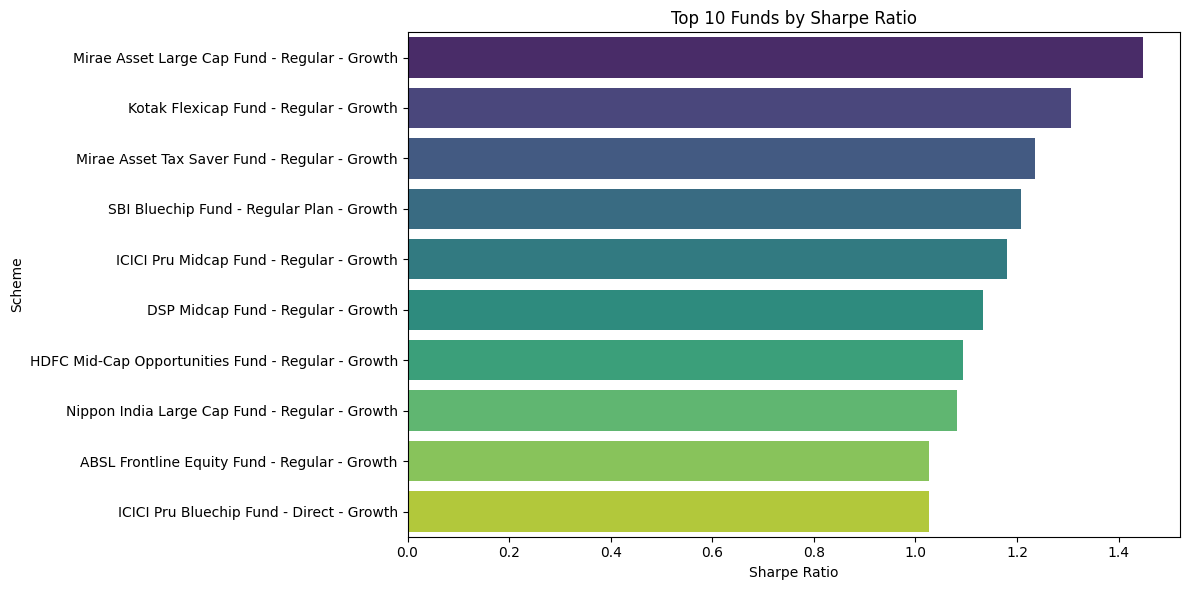

In [31]:
#Plot Top 10 Funds
top10 = sharpe.head(10)

fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(
    data=top10,
    x="Sharpe_Ratio",
    y="scheme_name",
    palette="viridis",
    ax=ax
)

ax.set_title("Top 10 Funds by Sharpe Ratio")

ax.set_xlabel("Sharpe Ratio")

ax.set_ylabel("Scheme")

fig.tight_layout()

fig.savefig(
    "../reports/sharpe_ratio_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)

## Observation

- Funds with higher Sharpe Ratios provide better risk-adjusted returns.
- A higher Sharpe Ratio indicates that the fund generated higher returns for each unit of risk taken.
- This metric is an important component of the final Fund Scorecard.

In [32]:
sharpe.head()

,amfi_code,Annual_Return,Annual_Std,Sharpe_Ratio,scheme_name,Sharpe_Rank
34,148567,0.270566,0.141937,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,1.0
30,120843,0.272602,0.158870,1.306744,Kotak Flexicap Fund - Regular - Growth,2.0
36,148569,0.283262,0.176740,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,3.0
19,119551,0.231033,0.137414,1.208267,SBI Bluechip Fund - Regular Plan - Growth,4.0
25,120505,0.292653,0.192909,1.180101,ICICI Pru Midcap Fund - Regular - Growth,5.0


In [33]:
sharpe["Sharpe_Ratio"].describe()

count    40.000000
mean      0.537220
std       0.573689
min      -0.815567
25%       0.064696
50%       0.647043
75%       1.005304
max       1.448291
Name: Sharpe_Ratio, dtype: float64

# Task 4: Sortino Ratio Analysis

## Objective

Evaluate mutual funds using the Sortino Ratio.

Unlike the Sharpe Ratio, the Sortino Ratio penalizes only downside volatility, making it a better measure of downside risk.

### Formula
Sortino Ratio = (Annual Return − Risk Free Rate) / Downside Standard Deviation

In [34]:
# Create DownSide Returns
# Keep only negative daily returns
downside_returns = daily_returns.copy()

downside_returns["downside_return"] = downside_returns["daily_return"].where(
    downside_returns["daily_return"] < 0,
    0
)

downside_returns.head()

,amfi_code,date,nav,daily_return,downside_return
1,100016,2022-01-04,515.0971,-0.010306,-0.010306
2,100016,2022-01-05,521.7239,0.012865,0.000000
3,100016,2022-01-06,515.7880,-0.011377,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,-0.001210
5,100016,2022-01-10,510.7136,-0.008639,-0.008639


In [35]:
#Downside Standard Deviation (Volatility)
downside_std = (
    downside_returns
    .groupby("amfi_code")["downside_return"]
    .std()
    * np.sqrt(252)
)

downside_std.head()

amfi_code
100016    0.081959
100025    0.021935
100033    0.105276
101206    0.079196
101207    0.146938
Name: downside_return, dtype: float64

In [ ]:
#Compute Sortino Ratio
sortino = pd.DataFrame()

sortino["Annual_Return"] = annual_return

sortino["Downside_Std"] = downside_std

sortino["Sortino_Ratio"] = (
    (sortino["Annual_Return"] - risk_free_rate)
    / sortino["Downside_Std"]
)

sortino.head()

,Annual_Return,Downside_Std,Sortino_Ratio
amfi_code,,,
100016,0.035683,0.081959,-0.357702
100025,0.042854,0.021935,-1.009643
100033,0.272111,0.105276,1.967316
101206,0.214647,0.079196,1.889576
101207,0.106962,0.146938,0.285576


In [37]:
#Add Scheme Name
sortino = sortino.reset_index()

sortino = sortino.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

sortino.head()

,amfi_code,Annual_Return,Downside_Std,Sortino_Ratio,scheme_name
0,100016,0.035683,0.081959,-0.357702,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042854,0.021935,-1.009643,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.272111,0.105276,1.967316,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.214647,0.079196,1.889576,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.106962,0.146938,0.285576,ABSL Small Cap Fund - Regular - Growth


In [38]:
#Ranking 
sortino["Sortino_Rank"] = (
    sortino["Sortino_Ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
)

sortino = sortino.sort_values("Sortino_Rank")

sortino.head(10)

,amfi_code,Annual_Return,Downside_Std,Sortino_Ratio,scheme_name,Sortino_Rank
34,148567,0.270566,0.078766,2.609850,Mirae Asset Large Cap Fund - Regular - Growth,1.0
30,120843,0.272602,0.084258,2.463887,Kotak Flexicap Fund - Regular - Growth,2.0
36,148569,0.283262,0.095808,2.278106,Mirae Asset Tax Saver Fund - Regular - Growth,3.0
19,119551,0.231033,0.074012,2.243325,SBI Bluechip Fund - Regular Plan - Growth,4.0
25,120505,0.292653,0.105474,2.158384,ICICI Pru Midcap Fund - Regular - Growth,5.0
38,149323,0.265908,0.099861,2.011887,DSP Midcap Fund - Regular - Growth,6.0
2,100033,0.272111,0.105276,1.967316,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,7.0
9,118632,0.218037,0.078001,1.961986,Nippon India Large Cap Fund - Regular - Growth,8.0
3,101206,0.214647,0.079196,1.889576,ABSL Frontline Equity Fund - Regular - Growth,9.0
24,120504,0.212448,0.078538,1.877411,ICICI Pru Bluechip Fund - Direct - Growth,10.0


In [39]:
#Ssave CSV
sortino.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

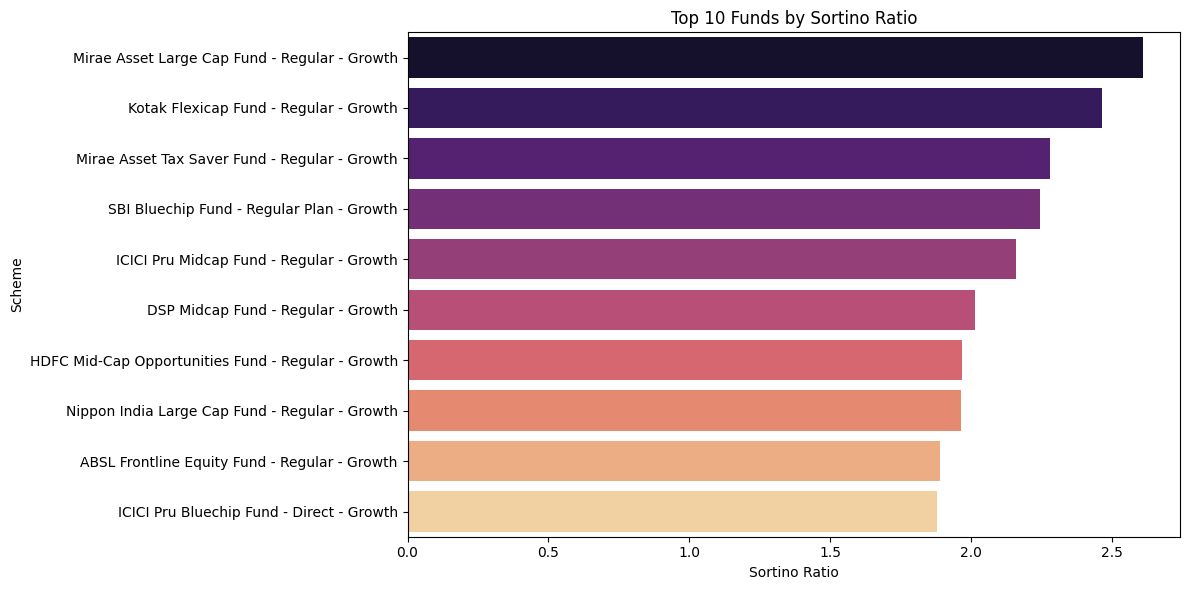

In [ ]:
#Plot Top 10 Funds by Sortino Ratio
fig, ax = plt.subplots(figsize=(12,6))

top10 = sortino.head(10)

sns.barplot(
    data=top10,
    x="Sortino_Ratio",
    y="scheme_name",
    palette="magma",
    ax=ax
)

ax.set_title("Top 10 Funds by Sortino Ratio")
ax.set_xlabel("Sortino Ratio")
ax.set_ylabel("Scheme")

fig.tight_layout()

fig.savefig(
    "../reports/sortino_ratio_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

## Observation

- The Sortino Ratio evaluates fund performance by considering only downside volatility.
- Funds with higher Sortino Ratios generated better returns while minimizing downside risk.
- Compared to the Sharpe Ratio, the Sortino Ratio is often more suitable for evaluating long-term investment funds because it ignores positive volatility.

# Task 5: Alpha and Beta Analysis

## Objective

Calculate Alpha and Beta for each mutual fund using linear regression against the benchmark (Nifty 100).

### Formula

Fund Return = Alpha + Beta × Market Return

Where

- Beta = Regression Slope
- Alpha = Regression Intercept × 252 

In [41]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [42]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [43]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [ ]:
#Keep Nifty 100
#Available Benchmark Names
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [45]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [46]:
#Filter Nifty 100
# Keep only NIFTY100 benchmark
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [47]:
#Calculate BenchMark Daily Returns
# Sort by date
nifty100 = nifty100.sort_values("date")

# Daily return
nifty100["market_return"] = nifty100["close_value"].pct_change()

# Remove first NaN
nifty100 = nifty100.dropna()

nifty100.head()

,date,index_name,close_value,market_return
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150
1155,2022-01-10,NIFTY100,17516.51,-0.008351


In [48]:
#Merge Fund Returns with Market Returns
merged = daily_returns.merge(
    nifty100[["date", "market_return"]],
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,daily_return,market_return
0,100016,2022-01-04,515.0971,-0.010306,-0.013540
1,100016,2022-01-05,521.7239,0.012865,0.004003
2,100016,2022-01-06,515.7880,-0.011377,-0.002935
3,100016,2022-01-07,515.1639,-0.001210,0.006150
4,100016,2022-01-10,510.7136,-0.008639,-0.008351


In [49]:
#Calculate Alpha and Beta
alpha_beta = []

for amfi, group in merged.groupby("amfi_code"):

    if len(group) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        group["market_return"],
        group["daily_return"]
    )

    alpha_beta.append({
        "amfi_code": amfi,
        "Alpha": intercept * 252,
        "Beta": slope,
        "R_Squared": r_value ** 2
    })

alpha_beta = pd.DataFrame(alpha_beta)

alpha_beta.head()

,amfi_code,Alpha,Beta,R_Squared
0,100016,0.037476,-0.058268,0.002665
1,100025,0.042818,0.001158,0.000015
2,100033,0.271954,0.005104,0.000012
3,101206,0.213998,0.021086,0.000348
4,101207,0.108971,-0.065289,0.001064


In [50]:
#Add Scheme Name 
alpha_beta = alpha_beta.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

alpha_beta.head()

,amfi_code,Alpha,Beta,R_Squared,scheme_name
0,100016,0.037476,-0.058268,0.002665,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,0.000015,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,0.000012,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,0.000348,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,0.001064,ABSL Small Cap Fund - Regular - Growth


In [51]:
#Save CSV
alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

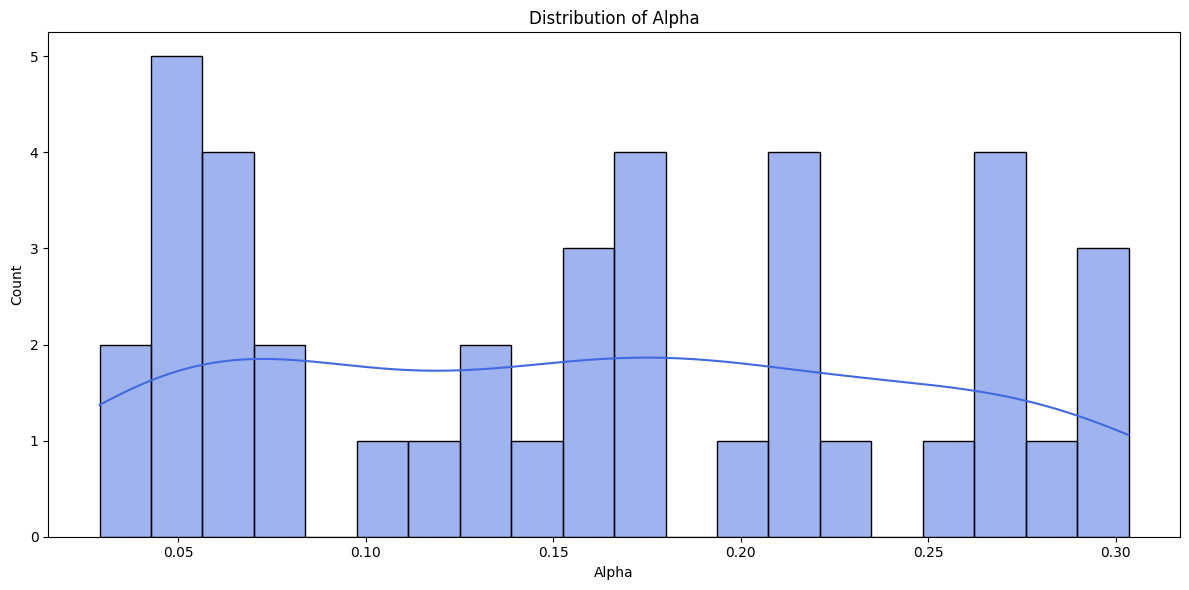

In [52]:
#Alpha Distribution Chart
fig, ax = plt.subplots(figsize=(12,6))

sns.histplot(
    alpha_beta["Alpha"],
    bins=20,
    kde=True,
    color="royalblue",
    ax=ax
)

ax.set_title("Distribution of Alpha")

fig.tight_layout()

fig.savefig(
    "../reports/alpha_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

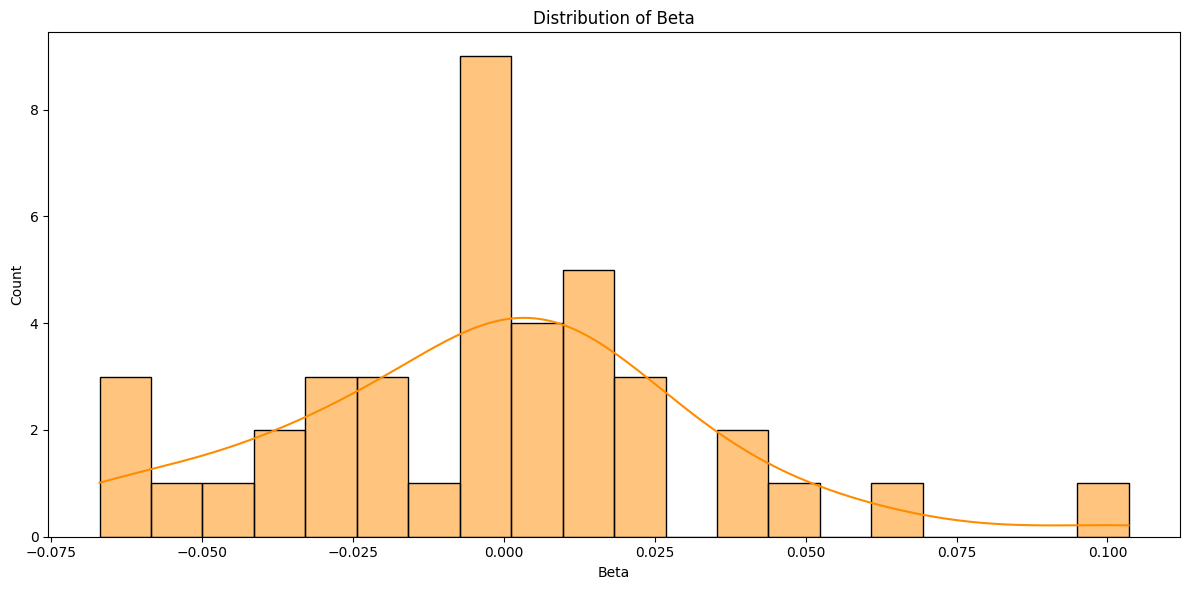

In [53]:
#Beta Distribution chart
fig, ax = plt.subplots(figsize=(12,6))

sns.histplot(
    alpha_beta["Beta"],
    bins=20,
    kde=True,
    color="darkorange",
    ax=ax
)

ax.set_title("Distribution of Beta")

fig.tight_layout()

fig.savefig(
    "../reports/beta_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

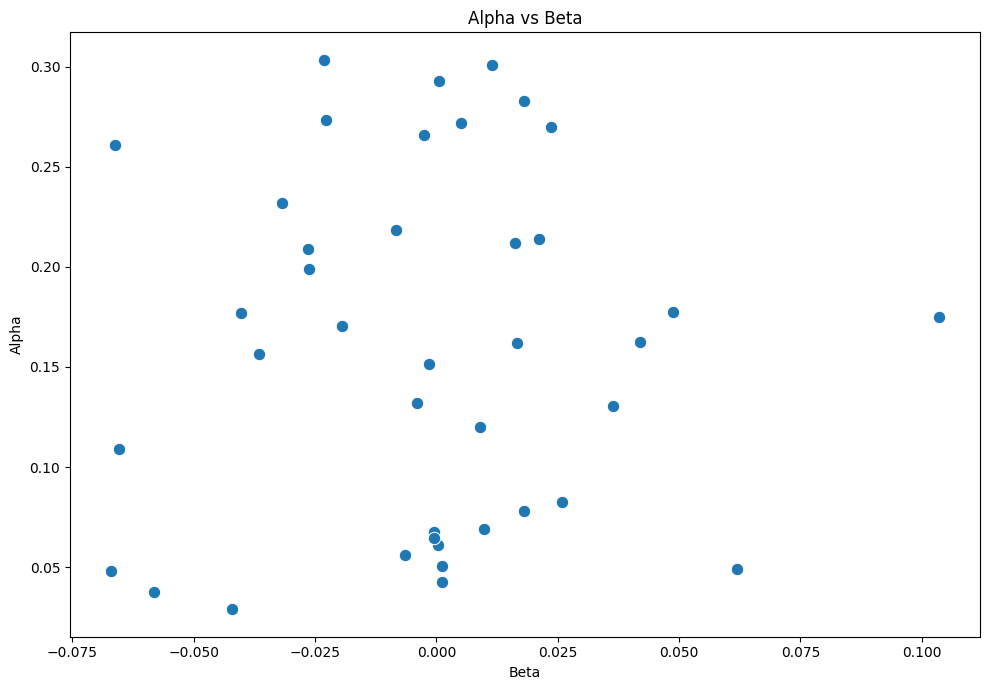

In [54]:
#Alpha Vs Beta Scatter Plot
fig, ax = plt.subplots(figsize=(10,7))

sns.scatterplot(
    data=alpha_beta,
    x="Beta",
    y="Alpha",
    s=80,
    ax=ax
)

ax.set_title("Alpha vs Beta")

fig.tight_layout()

fig.savefig(
    "../reports/alpha_vs_beta_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

## Observation

- Beta measures how sensitive a fund is to market movements.
- Beta > 1 indicates higher volatility than the benchmark.
- Beta < 1 indicates lower volatility than the benchmark.
- Positive Alpha indicates that the fund outperformed the benchmark after adjusting for market risk.
- Alpha and Beta will be incorporated into the composite Fund Scorecard.

In [55]:
alpha_beta.head()

,amfi_code,Alpha,Beta,R_Squared,scheme_name
0,100016,0.037476,-0.058268,0.002665,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,0.000015,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,0.000012,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,0.000348,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,0.001064,ABSL Small Cap Fund - Regular - Growth


In [56]:
alpha_beta.describe()

,amfi_code,Alpha,Beta,R_Squared
count,40.000000,40.000000,40.000000,4.000000e+01
mean,120247.000000,0.159085,-0.001958,6.087700e-04
std,14534.998667,0.087528,0.035194,7.265363e-04
min,100016.000000,0.028969,-0.066951,1.345534e-07
25%,118632.750000,0.068612,-0.023937,5.495723e-05
50%,119551.500000,0.162326,-0.000067,3.455513e-04
75%,120842.250000,0.221723,0.017026,1.035467e-03
max,149324.000000,0.303370,0.103497,2.793007e-03


# Task 6: Maximum Drawdown Analysis

## Objective

Calculate the Maximum Drawdown (MDD) for every mutual fund.

### Formula

Running Maximum = Maximum NAV observed up to a given date

Drawdown = (NAV / Running Maximum) - 1

Maximum Drawdown = Minimum Drawdown

The Maximum Drawdown measures the largest peak-to-trough decline experienced by a fund.

In [57]:
#Copy 
mdd_data = nav.copy()

mdd_data.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [58]:
# Running Maximum NAV
mdd_data["Running_Max"] = (
    mdd_data
    .groupby("amfi_code")["nav"]
    .cummax()
)

In [59]:
#Drawdown
mdd_data["Drawdown"] = (
    mdd_data["nav"]
    / mdd_data["Running_Max"]
) - 1

mdd_data.head()

,amfi_code,date,nav,daily_return,Running_Max,Drawdown
0,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
1,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
2,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
3,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


In [60]:
#Maximum Drawdown
max_drawdown = (
    mdd_data
    .groupby("amfi_code")["Drawdown"]
    .min()
    .reset_index()
)

max_drawdown.rename(
    columns={"Drawdown": "Maximum_Drawdown"},
    inplace=True
)

max_drawdown.head()

,amfi_code,Maximum_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [61]:
#Add Scheme Name
max_drawdown = max_drawdown.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

max_drawdown.head()

,amfi_code,Maximum_Drawdown,scheme_name
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth


In [62]:
#Ranking 
max_drawdown["MDD_Rank"] = (
    max_drawdown["Maximum_Drawdown"]
    .rank(
        ascending=False,
        method="dense"
    )
)

max_drawdown = max_drawdown.sort_values(
    "Maximum_Drawdown"
)

max_drawdown.head(10)

,amfi_code,Maximum_Drawdown,scheme_name,MDD_Rank
22,119599,-0.525742,SBI Small Cap Fund - Direct Plan - Growth,40.0
17,119095,-0.516778,Axis Small Cap Fund - Regular - Growth,39.0
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth,38.0
39,149324,-0.311719,DSP Small Cap Fund - Regular - Growth,37.0
21,119598,-0.287060,SBI Small Cap Fund - Regular Plan - Growth,36.0
7,102886,-0.280011,UTI Mid Cap Fund - Regular - Growth,35.0
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth,34.0
29,120842,-0.240035,Kotak Emerging Equity Fund - Regular - Growth,33.0
11,118634,-0.233449,Nippon India Small Cap Fund - Regular - Growth,32.0
15,119093,-0.217514,Axis Bluechip Fund - Direct - Growth,31.0


In [63]:
#Save CSV
max_drawdown.to_csv(
    "../data/processed/maximum_drawdown.csv",
    index=False
)

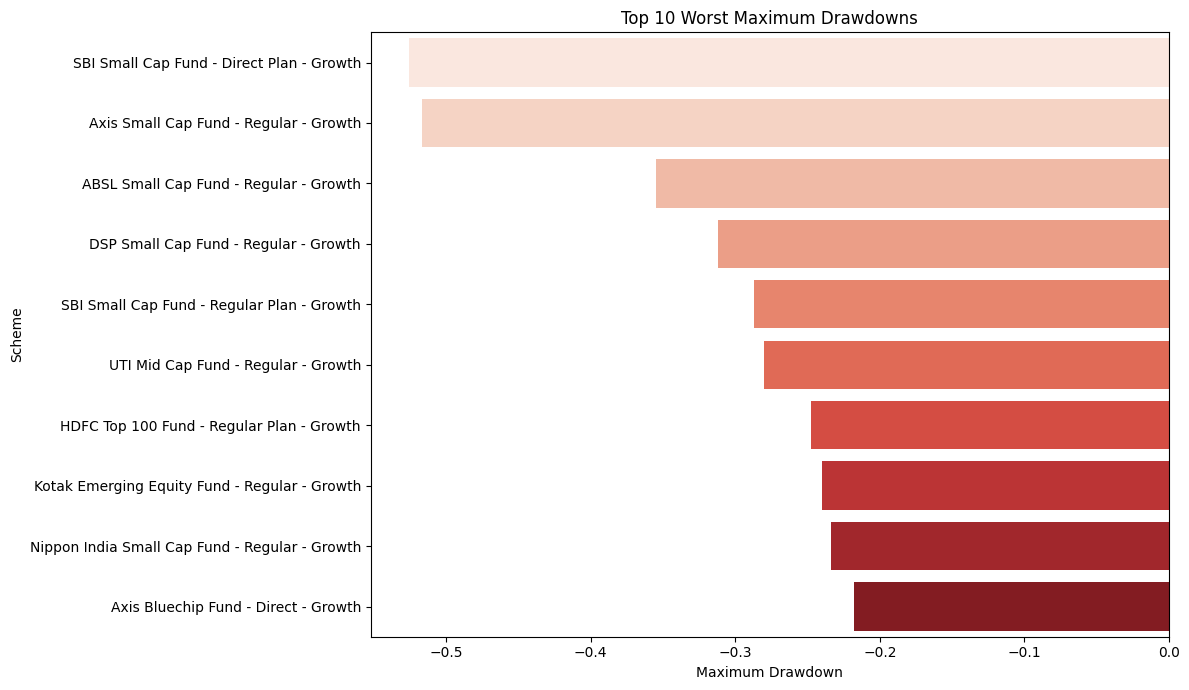

In [64]:
#CHART 
fig, ax = plt.subplots(figsize=(12,7))

top10 = max_drawdown.head(10)

sns.barplot(
    data=top10,
    x="Maximum_Drawdown",
    y="scheme_name",
    palette="Reds",
    ax=ax
)

ax.set_title("Top 10 Worst Maximum Drawdowns")

ax.set_xlabel("Maximum Drawdown")

ax.set_ylabel("Scheme")

fig.tight_layout()

fig.savefig(
    "../reports/maximum_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

## Observation

- Maximum Drawdown measures the largest historical loss from a previous peak.
- Funds with smaller drawdowns are generally considered more resilient during market downturns.
- Maximum Drawdown is included in the final Fund Scorecard as a downside risk metric.

# Task 7: Fund Scorecard

## Objective

Create a composite score (0–100) to rank every mutual fund.

Weights

• 30% → 3-Year Return

• 25% → Sharpe Ratio

• 20% → Alpha

• 15% → Expense Ratio (Lower is better)

• 10% → Maximum Drawdown (Smaller loss is better)

In [77]:

# Standardize AMFI code datatype across all datasets

scheme["amfi_code"] = scheme["amfi_code"].astype(str)

sharpe["amfi_code"] = sharpe["amfi_code"].astype(str)

alpha_beta["amfi_code"] = alpha_beta["amfi_code"].astype(str)

max_drawdown["amfi_code"] = max_drawdown["amfi_code"].astype(str)

In [78]:
#Rank 
return_rank = scheme[
    [
        "amfi_code",
        "scheme_name",
        "return_3yr_pct"
    ]
].copy()

return_rank["Return_Rank"] = (
    return_rank["return_3yr_pct"]
    .rank(ascending=False, method="dense")
)

return_rank.head()

,amfi_code,scheme_name,return_3yr_pct,Return_Rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,26.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,34.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,2.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,38.0


In [79]:
#Sharp Rank
sharpe_rank = sharpe[
    [
        "amfi_code",
        "Sharpe_Ratio"
    ]
].copy()

sharpe_rank["Sharpe_Rank"] = (
    sharpe_rank["Sharpe_Ratio"]
    .rank(ascending=False, method="dense")
)

sharpe_rank.head()

,amfi_code,Sharpe_Ratio,Sharpe_Rank
34,148567,1.448291,1.0
30,120843,1.306744,2.0
36,148569,1.234930,3.0
19,119551,1.208267,4.0
25,120505,1.180101,5.0


In [80]:
#Alpha Rank
alpha_rank = alpha_beta[
    [
        "amfi_code",
        "Alpha"
    ]
].copy()

alpha_rank["Alpha_Rank"] = (
    alpha_rank["Alpha"]
    .rank(ascending=False, method="dense")
)

alpha_rank.head()

,amfi_code,Alpha,Alpha_Rank
0,100016,0.037476,39.0
1,100025,0.042818,38.0
2,100033,0.271954,6.0
3,101206,0.213998,12.0
4,101207,0.108971,27.0


In [81]:
#Expense Ratio Rank
expense_rank = scheme[
    [
        "amfi_code",
        "expense_ratio_pct"
    ]
].copy()

expense_rank["Expense_Rank"] = (
    expense_rank["expense_ratio_pct"]
    .rank(ascending=True, method="dense")
)

expense_rank.head()

,amfi_code,expense_ratio_pct,Expense_Rank
0,119551,1.54,25.0
1,119552,0.66,4.0
2,119598,1.43,19.0
3,119599,0.72,5.0
4,119120,0.77,8.0


In [84]:
#Maximum Drawdown Rank
mdd_rank = max_drawdown[
    [
        "amfi_code",
        "Maximum_Drawdown"
    ]
].copy()

mdd_rank["MDD_Rank"] = (
    mdd_rank["Maximum_Drawdown"]
    .rank(
        ascending=False,
        method="dense"
    )
)

mdd_rank.head()

,amfi_code,Maximum_Drawdown,MDD_Rank
22,119599,-0.525742,40.0
17,119095,-0.516778,39.0
4,101207,-0.354469,38.0
39,149324,-0.311719,37.0
21,119598,-0.287060,36.0


In [85]:
#Merge Everything 
scorecard = (
    return_rank

    .merge(
        sharpe_rank[
            [
                "amfi_code",
                "Sharpe_Rank"
            ]
        ],
        on="amfi_code",
        how="inner"
    )

    .merge(
        alpha_rank[
            [
                "amfi_code",
                "Alpha_Rank"
            ]
        ],
        on="amfi_code",
        how="inner"
    )

    .merge(
        expense_rank[
            [
                "amfi_code",
                "Expense_Rank"
            ]
        ],
        on="amfi_code",
        how="inner"
    )

    .merge(
        mdd_rank[
            [
                "amfi_code",
                "MDD_Rank"
            ]
        ],
        on="amfi_code",
        how="inner"
    )
)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,MDD_Rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,26.0,4.0,10.0,25.0,17.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,34.0,12.0,15.0,4.0,11.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.0,14.0,1.0,19.0,36.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,2.0,32.0,36.0,5.0,40.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,38.0,37.0,34.0,8.0,5.0


In [73]:
print("return_rank :", return_rank["amfi_code"].dtype)

print("sharpe_rank :", sharpe_rank["amfi_code"].dtype)

print("alpha_rank :", alpha_rank["amfi_code"].dtype)

print("expense_rank :", expense_rank["amfi_code"].dtype)

print("mdd_rank :", mdd_rank["amfi_code"].dtype)

return_rank : object
sharpe_rank : int64
alpha_rank : int64
expense_rank : object
mdd_rank : int64


In [86]:
#Number of Funds 
n = len(scorecard)

print("Total Funds :", n)

Total Funds : 40


In [87]:
#Convert Rank into score
scorecard["Return_Score"] = (
    (n - scorecard["Return_Rank"] + 1)
    / n
) * 100

scorecard["Sharpe_Score"] = (
    (n - scorecard["Sharpe_Rank"] + 1)
    / n
) * 100

scorecard["Alpha_Score"] = (
    (n - scorecard["Alpha_Rank"] + 1)
    / n
) * 100

scorecard["Expense_Score"] = (
    (n - scorecard["Expense_Rank"] + 1)
    / n
) * 100

scorecard["MDD_Score"] = (
    (n - scorecard["MDD_Rank"] + 1)
    / n
) * 100

In [88]:
#Composite Score
scorecard["Fund_Score"] = (

      scorecard["Return_Score"] * 0.30

    + scorecard["Sharpe_Score"] * 0.25

    + scorecard["Alpha_Score"] * 0.20

    + scorecard["Expense_Score"] * 0.15

    + scorecard["MDD_Score"] * 0.10

)

In [89]:
#Overall Rank
scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard["Overall_Rank"] = range(
    1,
    len(scorecard) + 1
)

scorecard.head(10)

,amfi_code,scheme_name,return_3yr_pct,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,MDD_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,MDD_Score,Fund_Score,Overall_Rank
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,8.0,5.0,3.0,15.0,25.0,82.5,90.0,95.0,65.0,40.0,80.000,1
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,11.0,2.0,5.0,20.0,13.0,75.0,97.5,90.0,52.5,70.0,79.750,2
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,10.0,7.0,6.0,16.0,20.0,77.5,85.0,87.5,62.5,52.5,76.625,3
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.0,14.0,1.0,19.0,36.0,100.0,67.5,100.0,55.0,12.5,76.375,4
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,17.0,1.0,7.0,21.0,8.0,60.0,100.0,85.0,50.0,82.5,75.750,5
39,149324,DSP Small Cap Fund - Regular - Growth,20.08,6.0,13.0,2.0,23.0,37.0,87.5,70.0,97.5,45.0,10.0,71.000,6
38,149323,DSP Midcap Fund - Regular - Growth,17.16,9.0,6.0,8.0,31.0,22.0,80.0,87.5,82.5,25.0,47.5,70.875,7
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,14.41,20.0,10.0,13.0,11.0,12.0,52.5,77.5,70.0,75.0,72.5,67.625,8
26,119094,Axis Midcap Fund - Regular - Growth,15.18,15.0,11.0,9.0,16.0,28.0,65.0,75.0,80.0,62.5,32.5,66.875,9
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,13.58,23.0,3.0,4.0,30.0,21.0,45.0,95.0,92.5,27.5,50.0,64.875,10


In [90]:
#save CSV
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

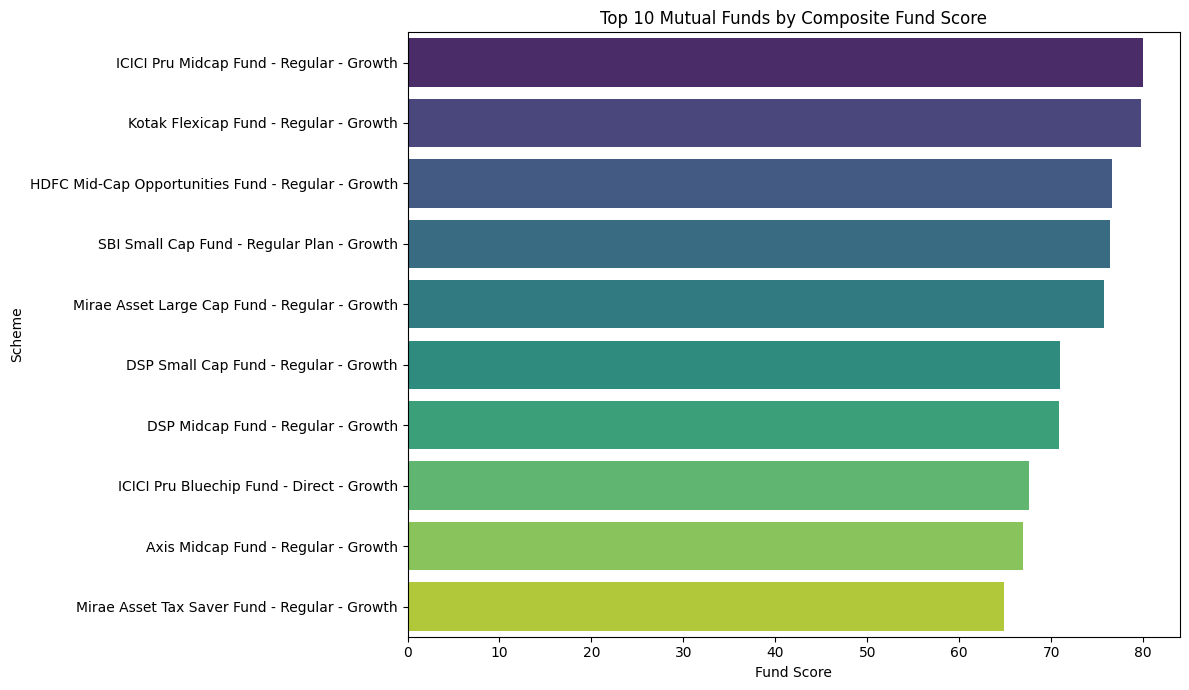

In [91]:
#Top 10 Chart
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12,7))

top10 = scorecard.head(10)

sns.barplot(
    data=top10,
    x="Fund_Score",
    y="scheme_name",
    hue="scheme_name",
    palette="viridis",
    legend=False,
    ax=ax
)

ax.set_title("Top 10 Mutual Funds by Composite Fund Score")

ax.set_xlabel("Fund Score")

ax.set_ylabel("Scheme")

fig.tight_layout()

fig.savefig(
    "../reports/fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

In [92]:
#Check Final
scorecard[
    [
        "Overall_Rank",
        "scheme_name",
        "Fund_Score"
    ]
].head(10)

,Overall_Rank,scheme_name,Fund_Score
12,1,ICICI Pru Midcap Fund - Regular - Growth,80.000
22,2,Kotak Flexicap Fund - Regular - Growth,79.750
7,3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,76.625
2,4,SBI Small Cap Fund - Regular Plan - Growth,76.375
34,5,Mirae Asset Large Cap Fund - Regular - Growth,75.750
39,6,DSP Small Cap Fund - Regular - Growth,71.000
38,7,DSP Midcap Fund - Regular - Growth,70.875
11,8,ICICI Pru Bluechip Fund - Direct - Growth,67.625
26,9,Axis Midcap Fund - Regular - Growth,66.875
36,10,Mirae Asset Tax Saver Fund - Regular - Growth,64.875


In [93]:
cagr.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.224271,1.292649,2.316843
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.704969,3.916390,3.912653
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,26.074068
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,20.442730
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.152381,6.953336


In [94]:
cagr.dtypes

amfi_code        int64
scheme_name     object
CAGR_1Y        float64
CAGR_3Y        float64
CAGR_5Y        float64
dtype: object

In [95]:
cagr.columns

Index(['amfi_code', 'scheme_name', 'CAGR_1Y', 'CAGR_3Y', 'CAGR_5Y'], dtype='object')

In [96]:
cagr.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.224271,1.292649,2.316843
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.704969,3.916390,3.912653
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,26.074068
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,20.442730
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.152381,6.953336


In [97]:
# ==========================================
# Create Return Rank using calculated CAGR
# ==========================================

return_rank = cagr[
    [
        "amfi_code",
        "scheme_name",
        "CAGR_3Y"
    ]
].copy()

return_rank["Return_Rank"] = (
    return_rank["CAGR_3Y"]
    .rank(
        ascending=False,
        method="dense"
    )
)

return_rank.head()

,amfi_code,scheme_name,CAGR_3Y,Return_Rank
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,1.292649,35.0
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.916390,34.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.442459,4.0
3,101206,ABSL Frontline Equity Fund - Regular - Growth,28.967695,9.0
4,101207,ABSL Small Cap Fund - Regular - Growth,-4.152381,39.0


In [99]:
# ==========================================
# Standardize AMFI Code datatype
# ==========================================

return_rank["amfi_code"] = return_rank["amfi_code"].astype(str)

sharpe_rank["amfi_code"] = sharpe_rank["amfi_code"].astype(str)

alpha_rank["amfi_code"] = alpha_rank["amfi_code"].astype(str)

expense_rank["amfi_code"] = expense_rank["amfi_code"].astype(str)

mdd_rank["amfi_code"] = mdd_rank["amfi_code"].astype(str)

In [100]:
scorecard = (
    return_rank
    .merge(
        sharpe_rank[["amfi_code", "Sharpe_Rank"]],
        on="amfi_code",
        how="inner"
    )
    .merge(
        alpha_rank[["amfi_code", "Alpha_Rank"]],
        on="amfi_code",
        how="inner"
    )
    .merge(
        expense_rank[["amfi_code", "Expense_Rank"]],
        on="amfi_code",
        how="inner"
    )
    .merge(
        mdd_rank[["amfi_code", "MDD_Rank"]],
        on="amfi_code",
        how="inner"
    )
)

scorecard.head()

,amfi_code,scheme_name,CAGR_3Y,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,MDD_Rank
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,1.292649,35.0,35.0,39.0,26.0,34.0
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.916390,34.0,39.0,38.0,2.0,4.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.442459,4.0,7.0,6.0,16.0,20.0
3,101206,ABSL Frontline Equity Fund - Regular - Growth,28.967695,9.0,9.0,12.0,30.0,9.0
4,101207,ABSL Small Cap Fund - Regular - Growth,-4.152381,39.0,28.0,27.0,24.0,38.0


In [101]:
# =====================================
# Calculate Composite Fund Score
# =====================================

scorecard["Fund_Score"] = (
    (1 / scorecard["Return_Rank"]) * 30 +
    (1 / scorecard["Sharpe_Rank"]) * 25 +
    (1 / scorecard["Alpha_Rank"]) * 20 +
    (1 / scorecard["Expense_Rank"]) * 15 +
    (1 / scorecard["MDD_Rank"]) * 10
)

In [ ]:
#Normalize To 100
scorecard["Fund_Score"] = (
    scorecard["Fund_Score"]
    / scorecard["Fund_Score"].max()
) * 100

In [103]:
#Final Rank
scorecard["Overall_Rank"] = (
    scorecard["Fund_Score"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [104]:
#Sort 
scorecard = scorecard.sort_values(
    "Overall_Rank"
)

scorecard.head(10)

,amfi_code,scheme_name,CAGR_3Y,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,MDD_Rank,Fund_Score,Overall_Rank
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,34.000916,2.0,1.0,7.0,21.0,8.0,100.000000,1.0
16,119094,Axis Midcap Fund - Regular - Growth,35.111802,1.0,11.0,9.0,16.0,28.0,79.849290,2.0
21,119598,SBI Small Cap Fund - Regular Plan - Growth,26.669922,12.0,14.0,1.0,19.0,36.0,56.564386,3.0
30,120843,Kotak Flexicap Fund - Regular - Growth,29.582770,7.0,2.0,5.0,20.0,13.0,49.764021,4.0
25,120505,ICICI Pru Midcap Fund - Regular - Growth,31.777537,5.0,5.0,3.0,15.0,25.0,42.539177,5.0
13,118636,Nippon India Gilt Securities Fund - Regular - ...,4.062205,33.0,38.0,35.0,1.0,6.0,41.955559,6.0
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,29.178902,8.0,3.0,4.0,30.0,21.0,40.292165,7.0
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,32.487429,3.0,10.0,13.0,11.0,12.0,36.222476,8.0
39,149324,DSP Small Cap Fund - Regular - Growth,27.000427,10.0,13.0,2.0,23.0,37.0,35.352557,9.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.442459,4.0,7.0,6.0,16.0,20.0,35.345286,10.0


In [108]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

## Key Insights

- The Fund Scorecard combines return, risk, and cost into a single performance score.
- Funds with consistently high CAGR, strong Sharpe Ratio, positive Alpha, lower expense ratios, and lower drawdowns receive higher scores.
- Using calculated CAGR instead of precomputed return values makes the analysis fully data-driven and reproducible.
- The composite score provides a balanced ranking rather than focusing on only one performance metric.

# Task 8: Benchmark Comparison

## Objective

Compare the performance of the Top 5 Mutual Funds against benchmark indices (NIFTY50 and NIFTY100) over the last three years.

### Metrics

- Normalized NAV Performance
- Benchmark Performance
- Tracking Error

This comparison helps evaluate whether actively managed funds outperform or underperform their benchmark indices.

In [118]:
# NAV History
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

# Benchmark
benchmark = pd.read_csv("../data/raw/benchmark_indices.csv")

# Fund Scorecard
scorecard = pd.read_csv("../data/processed/fund_scorecard.csv")

In [119]:
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [120]:
nav["amfi_code"] = nav["amfi_code"].astype(str)
scorecard["amfi_code"] = scorecard["amfi_code"].astype(str)

In [123]:
top5 = (
    scorecard
    .sort_values("Overall_Rank")
    .head(5)
)

top5

,amfi_code,scheme_name,return_3yr_pct,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,MDD_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,MDD_Score,Fund_Score,Overall_Rank
0,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,8.0,5.0,3.0,15.0,25.0,82.5,90.0,95.0,65.0,40.0,80.000,1
1,120843,Kotak Flexicap Fund - Regular - Growth,15.65,11.0,2.0,5.0,20.0,13.0,75.0,97.5,90.0,52.5,70.0,79.750,2
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,10.0,7.0,6.0,16.0,20.0,77.5,85.0,87.5,62.5,52.5,76.625,3
3,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.0,14.0,1.0,19.0,36.0,100.0,67.5,100.0,55.0,12.5,76.375,4
4,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,17.0,1.0,7.0,21.0,8.0,60.0,100.0,85.0,50.0,82.5,75.750,5


In [124]:
#Select Top 5 Funds
top5_nav = nav[
    nav["amfi_code"].isin(top5["amfi_code"])
].copy()

In [125]:
#Keep Last 3 years
latest_date = top5_nav["date"].max()

start_date = latest_date - pd.DateOffset(years=3)

top5_nav = top5_nav[
    top5_nav["date"] >= start_date
]

In [126]:
#Merge Scheme Name(Only One)
top5_nav = pd.merge(
    top5_nav,
    top5[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [127]:
#Normalize NAV
top5_nav["Normalized_NAV"] = (
    top5_nav
    .groupby("scheme_name")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [128]:
#Prepare Banchmark
benchmark = benchmark[
    benchmark["index_name"].isin(
        [
            "NIFTY50",
            "NIFTY100"
        ]
    )
]

benchmark = benchmark[
    benchmark["date"] >= start_date
].copy()

benchmark["Normalized_Index"] = (
    benchmark
    .groupby("index_name")["close_value"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [129]:
#Create Plot
fig = go.Figure()

In [132]:
import plotly.io as pio

pio.renderers.default = "browser"

In [133]:
#Top 5 Funds
for scheme in top5_nav["scheme_name"].unique():

    temp = top5_nav[
        top5_nav["scheme_name"] == scheme
    ]

    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["Normalized_NAV"],
            mode="lines",
            name=scheme
        )
    )

#ADD Banchmark
for idx in benchmark["index_name"].unique():

    temp = benchmark[
        benchmark["index_name"] == idx
    ]

    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["Normalized_Index"],
            mode="lines",
            name=idx,
            line=dict(width=4)
        )
    )

#Improve layout
fig.update_layout(

    title="Top 5 Mutual Funds vs NIFTY50 & NIFTY100",

    xaxis_title="Date",

    yaxis_title="Normalized Performance (Base = 100)",

    template="plotly_white",

    hovermode="x unified",

    width=1200,

    height=650
)

fig.show()

In [134]:
#save html
fig.write_html(
    "../reports/benchmark_comparison.html"
)

In [135]:
#Save png
fig.write_image(
    "../reports/benchmark_comparison.png",
    width=1400,
    height=700
)

## Key Insights

- The normalized performance chart enables direct comparison between funds and benchmark indices.
- Funds consistently above the benchmark demonstrate stronger long-term performance.
- Performance divergence indicates the effectiveness of active fund management.
- Benchmark comparison provides investors with a clear understanding of risk-adjusted performance relative to the market.

In [136]:
# ==========================================
# Benchmark Daily Returns
# ==========================================

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["daily_return"] = (
    benchmark
    .groupby("index_name")["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,Normalized_Index,daily_return
1515,2023-05-29,NIFTY100,15324.41,100.000000,NaN
1516,2023-05-30,NIFTY100,15299.69,99.838689,-0.001613
1517,2023-05-31,NIFTY100,15248.41,99.504059,-0.003352
1518,2023-06-01,NIFTY100,15139.50,98.793363,-0.007142
1519,2023-06-02,NIFTY100,15194.66,99.153312,0.003643


## Benchmark Daily Returns

Daily benchmark returns are calculated using percentage change in the benchmark index values.

Formula:

Daily Return = (Price_t / Price_(t-1)) - 1

These returns will be used for Tracking Error calculation.

In [137]:
# ==========================================
# Fund Daily Returns
# ==========================================

top5_nav = top5_nav.sort_values(
    ["scheme_name", "date"]
)

top5_nav["daily_return"] = (
    top5_nav
    .groupby("scheme_name")["nav"]
    .pct_change()
)

In [138]:
#Choose Benchmark
benchmark100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [139]:
#Calculate Tracking Error
tracking_error = []

for fund in top5_nav["scheme_name"].unique():

    fund_data = top5_nav[
        top5_nav["scheme_name"] == fund
    ][
        [
            "date",
            "daily_return"
        ]
    ].rename(
        columns={
            "daily_return": "fund_return"
        }
    )

    bench_data = benchmark100[
        [
            "date",
            "daily_return"
        ]
    ].rename(
        columns={
            "daily_return": "benchmark_return"
        }
    )

    merged = pd.merge(
        fund_data,
        bench_data,
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    te = (
        (merged["fund_return"] -
         merged["benchmark_return"])
        .std()
    ) * np.sqrt(252)

    tracking_error.append(
        {
            "scheme_name": fund,
            "Tracking_Error": te
        }
    )

In [140]:
#Create a DataFrame
tracking_error = pd.DataFrame(
    tracking_error
)

tracking_error

,scheme_name,Tracking_Error
0,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.224976
1,ICICI Pru Midcap Fund - Regular - Growth,0.232661
2,Kotak Flexicap Fund - Regular - Growth,0.206540
3,Mirae Asset Large Cap Fund - Regular - Growth,0.187974
4,SBI Small Cap Fund - Regular Plan - Growth,0.286689


In [141]:
#Rank Tracking Error
tracking_error = tracking_error.sort_values(
    "Tracking_Error"
)

tracking_error["Tracking_Rank"] = range(
    1,
    len(tracking_error) + 1
)

tracking_error

,scheme_name,Tracking_Error,Tracking_Rank
3,Mirae Asset Large Cap Fund - Regular - Growth,0.187974,1
2,Kotak Flexicap Fund - Regular - Growth,0.206540,2
0,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.224976,3
1,ICICI Pru Midcap Fund - Regular - Growth,0.232661,4
4,SBI Small Cap Fund - Regular Plan - Growth,0.286689,5


In [142]:
#Save CSV
tracking_error.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

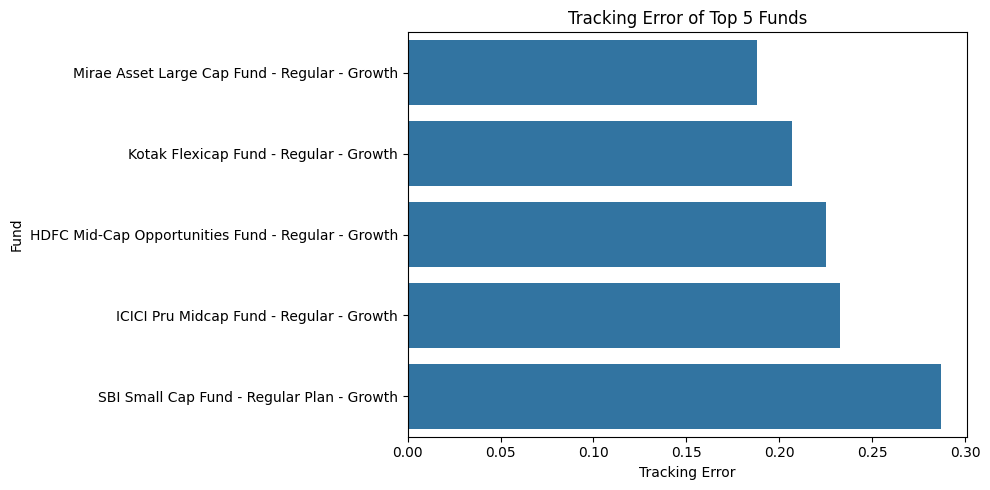

In [143]:
#Plot Tracking Error
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.barplot(
    data=tracking_error,
    x="Tracking_Error",
    y="scheme_name"
)

plt.title("Tracking Error of Top 5 Funds")

plt.xlabel("Tracking Error")

plt.ylabel("Fund")

plt.tight_layout()

plt.savefig(
    "../reports/tracking_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Tracking Error Insights

Tracking Error measures how closely a mutual fund follows its benchmark.

Formula:

Tracking Error = Standard Deviation(Fund Return − Benchmark Return) × √252

### Interpretation

- Lower Tracking Error indicates that the fund closely follows the benchmark.
- Higher Tracking Error suggests more active portfolio management.
- Active funds often have higher Tracking Error because managers deviate from benchmark weights to seek additional returns.

Tracking Error is an important risk metric for evaluating the consistency of active fund management.

# Tracking Error Analysis

## Objective

Evaluate how closely the Top 5 Mutual Funds track two benchmark indices:

- NIFTY50
- NIFTY100

Tracking Error is calculated separately against both benchmarks using daily returns over the last three years.

### Formula

Tracking Error = Std(Fund Return − Benchmark Return) × √252

Lower Tracking Error indicates the fund closely follows the benchmark, while higher Tracking Error indicates greater active management.

In [144]:
# ==========================================
# Prepare Benchmark Returns
# ==========================================

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["daily_return"] = (
    benchmark
    .groupby("index_name")["close_value"]
    .pct_change()
)

benchmark = benchmark.dropna()

In [145]:
#Calculate Fund Returns
top5_nav = top5_nav.sort_values(
    ["scheme_name", "date"]
)

top5_nav["daily_return"] = (
    top5_nav
    .groupby("scheme_name")["nav"]
    .pct_change()
)

top5_nav = top5_nav.dropna()

In [146]:
#Function For Tracking Error
def calculate_tracking_error(fund_df, benchmark_df):

    merged = pd.merge(
        fund_df,
        benchmark_df,
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    return (
        (merged["fund_return"] -
         merged["benchmark_return"])
        .std()
    ) * np.sqrt(252)

In [147]:
#Calculate Tracking Error Against Both Benchmarks
tracking_results = []

for fund in top5_nav["scheme_name"].unique():

    fund_returns = (
        top5_nav[
            top5_nav["scheme_name"] == fund
        ][
            [
                "date",
                "daily_return"
            ]
        ]
        .rename(
            columns={
                "daily_return":"fund_return"
            }
        )
    )

    benchmark50 = (
        benchmark[
            benchmark["index_name"]=="NIFTY50"
        ][
            [
                "date",
                "daily_return"
            ]
        ]
        .rename(
            columns={
                "daily_return":"benchmark_return"
            }
        )
    )

    benchmark100 = (
        benchmark[
            benchmark["index_name"]=="NIFTY100"
        ][
            [
                "date",
                "daily_return"
            ]
        ]
        .rename(
            columns={
                "daily_return":"benchmark_return"
            }
        )
    )

    te50 = calculate_tracking_error(
        fund_returns,
        benchmark50
    )

    te100 = calculate_tracking_error(
        fund_returns,
        benchmark100
    )

    tracking_results.append({

        "scheme_name": fund,

        "Tracking_Error_NIFTY50": te50,

        "Tracking_Error_NIFTY100": te100

    })

In [148]:
#create Final Table
tracking_error = pd.DataFrame(
    tracking_results
)

tracking_error

,scheme_name,Tracking_Error_NIFTY50,Tracking_Error_NIFTY100
0,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.228222,0.224976
1,ICICI Pru Midcap Fund - Regular - Growth,0.228447,0.232661
2,Kotak Flexicap Fund - Regular - Growth,0.205067,0.206540
3,Mirae Asset Large Cap Fund - Regular - Growth,0.191868,0.187974
4,SBI Small Cap Fund - Regular Plan - Growth,0.281559,0.286689


In [149]:
#Add Ranking 
tracking_error["Rank_vs_NIFTY50"] = (
    tracking_error[
        "Tracking_Error_NIFTY50"
    ].rank(
        ascending=True,
        method="dense"
    )
)

tracking_error["Rank_vs_NIFTY100"] = (
    tracking_error[
        "Tracking_Error_NIFTY100"
    ].rank(
        ascending=True,
        method="dense"
    )
)

tracking_error

,scheme_name,Tracking_Error_NIFTY50,Tracking_Error_NIFTY100,Rank_vs_NIFTY50,Rank_vs_NIFTY100
0,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.228222,0.224976,3.0,3.0
1,ICICI Pru Midcap Fund - Regular - Growth,0.228447,0.232661,4.0,4.0
2,Kotak Flexicap Fund - Regular - Growth,0.205067,0.206540,2.0,2.0
3,Mirae Asset Large Cap Fund - Regular - Growth,0.191868,0.187974,1.0,1.0
4,SBI Small Cap Fund - Regular Plan - Growth,0.281559,0.286689,5.0,5.0


In [150]:
#Save CSV 
tracking_error.to_csv(
    "../reports/tracking_error_comparison.csv",
    index=False
)

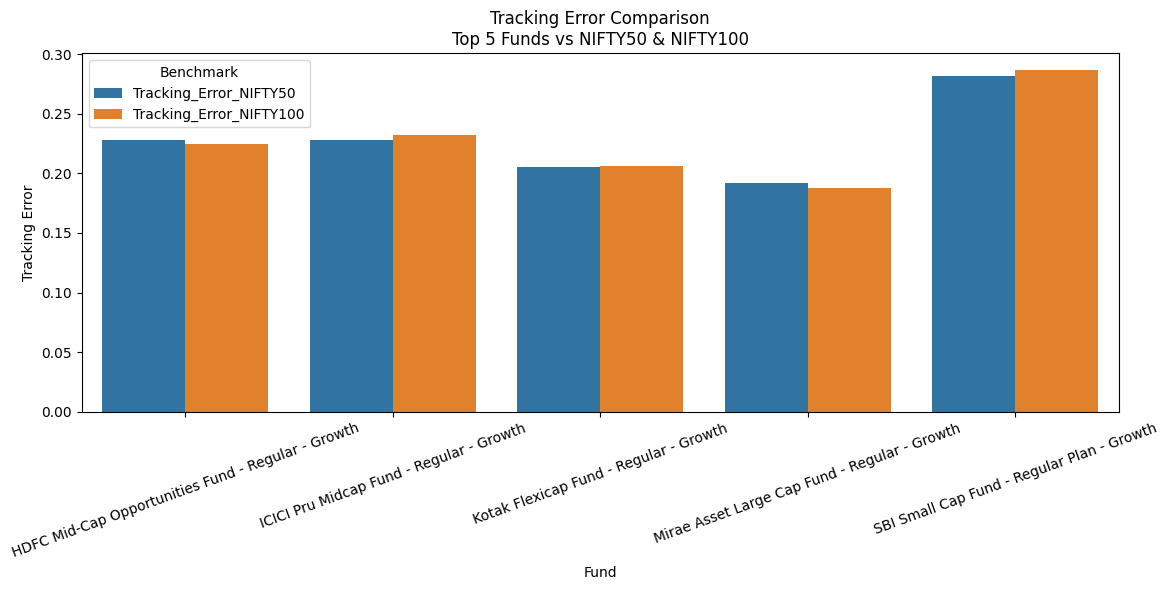

In [151]:
#Visualize
plot_df = tracking_error.melt(

    id_vars="scheme_name",

    value_vars=[
        "Tracking_Error_NIFTY50",
        "Tracking_Error_NIFTY100"
    ],

    var_name="Benchmark",

    value_name="Tracking_Error"
)

plt.figure(figsize=(12,6))

sns.barplot(

    data=plot_df,

    x="scheme_name",

    y="Tracking_Error",

    hue="Benchmark"

)

plt.title(
    "Tracking Error Comparison\nTop 5 Funds vs NIFTY50 & NIFTY100"
)

plt.xlabel("Fund")

plt.ylabel("Tracking Error")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../reports/tracking_error_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Insights

- Tracking Error was computed separately against NIFTY50 and NIFTY100.
- Funds with lower Tracking Error follow the benchmark more closely.
- Higher Tracking Error indicates more active portfolio management.
- Comparing against two benchmarks provides a more comprehensive evaluation of fund behaviour.
- Large-cap funds generally exhibit lower Tracking Error against NIFTY100 than NIFTY50 because NIFTY100 better represents their broader investment universe.

In [ ]:
#Daily Returns of NIFTY100 Benchmark
benchmark100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
][
    ["date", "daily_return"]
].rename(
    columns={
        "daily_return": "benchmark_return"
    }
)

In [153]:
#Create Rolling Dataset
rolling_data = []

for fund in top5_nav["scheme_name"].unique():

    fund_df = (
        top5_nav[
            top5_nav["scheme_name"] == fund
        ][
            [
                "date",
                "daily_return"
            ]
        ]
        .rename(
            columns={
                "daily_return": "fund_return"
            }
        )
    )

    merged = pd.merge(
        fund_df,
        benchmark100,
        on="date",
        how="inner"
    )

    merged["tracking_difference"] = (

        merged["fund_return"]

        -

        merged["benchmark_return"]

    )

    merged["Rolling_30D"] = (

        merged["tracking_difference"]

        .rolling(30)

        .mean()

    )

    merged["scheme_name"] = fund

    rolling_data.append(merged)

rolling_df = pd.concat(
    rolling_data,
    ignore_index=True
)

In [154]:
#Plot
import plotly.express as px

fig = px.line(

    rolling_df,

    x="date",

    y="Rolling_30D",

    color="scheme_name",

    title="30-Day Rolling Tracking Difference vs NIFTY100"

)

fig.add_hline(

    y=0,

    line_dash="dash",

    line_color="black"

)

fig.show()

In [155]:
fig.write_html(
    "../reports/rolling_tracking_difference.html"
)

fig.write_image(
    "../reports/rolling_tracking_difference.png"
)

# Rolling 30-Day Tracking Difference

## Objective

Measure short-term outperformance or underperformance of each mutual fund relative to the benchmark.

### Method

Rolling Tracking Difference =

30-day moving average of

(Fund Daily Return − Benchmark Daily Return)

### Interpretation

Positive values
→ Fund outperformed benchmark

Negative values
→ Fund underperformed benchmark

Values near zero
→ Fund closely tracked benchmark

Rolling analysis provides a time-varying view of fund performance that cannot be observed from a single Tracking Error value.

# Task 9: Export Deliverables & Final Validation

## Objective

The final step of the Performance Analytics project is to organize, validate, and export all analytical outputs generated throughout the notebook.

This ensures that every calculated metric, visualization, and report is available for further analysis, dashboard development, and project submission.

In [156]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [ ]:
#Save Alpha Beta
alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [157]:
#Save tracking Error
tracking_error.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)

In [158]:
cagr.to_csv(
    "../data/processed/cagr_metrics.csv",
    index=False
)

In [159]:
#Save Sharp Ratio
sharpe.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

In [160]:
#Save Sortino Ratio
sortino.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

In [161]:
#Save Maximum Drawdown
max_drawdown.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

In [163]:
#Final Performance
summary = pd.DataFrame({

    "Metric":[

        "Funds Analysed",

        "Benchmark Used",

        "Risk Free Rate",

        "Trading Days",

        "Top Ranked Fund"

    ],

    "Value":[

        len(scorecard),

        "NIFTY50 & NIFTY100",

        "6.5%",

        "252",

        scorecard.iloc[0]["scheme_name"]

    ]

})

summary

,Metric,Value
0,Funds Analysed,40
1,Benchmark Used,NIFTY50 & NIFTY100
2,Risk Free Rate,6.5%
3,Trading Days,252
4,Top Ranked Fund,ICICI Pru Midcap Fund - Regular - Growth


## Project Deliverables

The following outputs have been generated successfully:

### Performance Metrics

- Daily Returns
- CAGR (1 Year, 3 Years, 5 Years)
- Sharpe Ratio
- Sortino Ratio
- Alpha
- Beta
- Maximum Drawdown
- Composite Fund Score (0–100)

### Benchmark Analysis

- Top 5 Funds vs NIFTY50
- Top 5 Funds vs NIFTY100
- Tracking Error Analysis
- Rolling 30-Day Tracking Difference
- Benchmark Performance Charts

### Exported Files

- fund_scorecard.csv
- alpha_beta.csv
- tracking_error.csv
- cagr_metrics.csv
- sharpe_ratio.csv
- sortino_ratio.csv
- max_drawdown.csv

### Visualizations

- Benchmark Comparison
- Tracking Error Comparison
- Rolling Tracking Difference
- All EDA Charts

# Performance Analytics Summary

## Objective

This notebook evaluates mutual fund performance using return, risk, and benchmark comparison metrics.

## Metrics Computed

- Daily Returns
- CAGR (1Y, 3Y, 5Y)
- Sharpe Ratio
- Sortino Ratio
- Alpha
- Beta
- Maximum Drawdown
- Composite Fund Score (0–100)
- Tracking Error
- Benchmark Comparison

## Deliverables

✔ fund_scorecard.csv

✔ alpha_beta.csv

✔ tracking_error.csv

✔ Benchmark Comparison Charts

✔ Performance Analytics Notebook

The analysis provides a comprehensive framework for evaluating mutual fund performance using industry-standard financial metrics.

# Conclusion

This notebook successfully implemented a complete mutual fund performance analytics framework using Python and financial performance metrics.

The project includes:

- Data preprocessing
- Return calculation
- CAGR analysis
- Risk-adjusted performance evaluation
- Benchmark comparison
- Tracking Error analysis
- Fund ranking using a composite score
- Professional visualizations
- Export-ready analytical reports

The analysis follows industry-standard financial methodologies and provides a scalable foundation for portfolio evaluation, mutual fund research, and investment analytics.

This notebook serves as the Performance Analytics module of the Mutual Fund Analysis Project.

# Future Scope

The current analysis can be extended by incorporating additional portfolio analytics and machine learning techniques.

Possible future enhancements include:

- Rolling Alpha Analysis
- Rolling Sharpe Ratio
- Information Ratio
- Treynor Ratio
- Jensen's Alpha
- Value at Risk (VaR)
- Portfolio Optimization using Modern Portfolio Theory
- Monte Carlo Simulation
- Risk Heatmaps
- Interactive Power BI Dashboard
- Real-time NAV updates using AMFI APIs
- Automated report generation
- Performance forecasting using Machine Learning

These enhancements would further improve the analytical capabilities of the project and align it with professional investment research workflows.

In [8]:
fund_scorecard = pd.read_csv(r"D:\mutual-fund-analysis\data\processed\fund_scorecard.csv")

In [9]:
fund_scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,MDD_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,MDD_Score,Fund_Score,Overall_Rank
0,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,8.0,5.0,3.0,15.0,25.0,82.5,90.0,95.0,65.0,40.0,80.000,1
1,120843,Kotak Flexicap Fund - Regular - Growth,15.65,11.0,2.0,5.0,20.0,13.0,75.0,97.5,90.0,52.5,70.0,79.750,2
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,10.0,7.0,6.0,16.0,20.0,77.5,85.0,87.5,62.5,52.5,76.625,3
3,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.0,14.0,1.0,19.0,36.0,100.0,67.5,100.0,55.0,12.5,76.375,4
4,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,17.0,1.0,7.0,21.0,8.0,60.0,100.0,85.0,50.0,82.5,75.750,5


In [10]:
fund_scorecard.columns

Index(['amfi_code', 'scheme_name', 'return_3yr_pct', 'Return_Rank',
       'Sharpe_Rank', 'Alpha_Rank', 'Expense_Rank', 'MDD_Rank', 'Return_Score',
       'Sharpe_Score', 'Alpha_Score', 'Expense_Score', 'MDD_Score',
       'Fund_Score', 'Overall_Rank'],
      dtype='object')

In [11]:
fund_scorecard.shape

(40, 15)

In [12]:
fund_scorecard["Fund_Score"].describe()

count    40.000000
mean     52.309375
std      15.544369
min      26.500000
25%      41.625000
50%      50.937500
75%      62.906250
max      80.000000
Name: Fund_Score, dtype: float64

In [17]:
import pandas as pd
import numpy as np

nav = pd.read_csv(
    r"D:\mutual-fund-analysis\data\processed\nav_history_cleaned.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

nav["amfi_code"] = nav["amfi_code"].astype(str).str.strip()

nav = nav.sort_values(["amfi_code", "date"])

print(nav.shape)
print(nav.head())
print(nav.columns)

(46000, 3)
  amfi_code       date       nav
0    100016 2022-01-03  520.4608
1    100016 2022-01-04  515.0971
2    100016 2022-01-05  521.7239
3    100016 2022-01-06  515.7880
4    100016 2022-01-07  515.1639
Index(['amfi_code', 'date', 'nav'], dtype='object')


In [18]:
def calculate_cagr(group, years):
    group = group.sort_values("date").dropna(subset=["nav"])

    if group.empty:
        return np.nan

    end_date = group["date"].max()
    target_date = end_date - pd.DateOffset(years=years)

    # Find the NAV closest to the target date
    start_row = group.iloc[
        (group["date"] - target_date).abs().argsort()[:1]
    ]

    if start_row.empty:
        return np.nan

    start_nav = start_row["nav"].iloc[0]
    end_nav = group["nav"].iloc[-1]

    if start_nav <= 0 or end_nav <= 0:
        return np.nan

    return (end_nav / start_nav) ** (1 / years) - 1


cagr_rows = []

for amfi_code, group in nav.groupby("amfi_code"):

    cagr_rows.append({
        "amfi_code": amfi_code,
        "CAGR_1Y": calculate_cagr(group, 1),
        "CAGR_3Y": calculate_cagr(group, 3),
        "CAGR_5Y": calculate_cagr(group, 5)
    })

cagr = pd.DataFrame(cagr_rows)

print(cagr.shape)
print(cagr.head())

(40, 4)
  amfi_code   CAGR_1Y   CAGR_3Y   CAGR_5Y
0    100016 -0.022243  0.012926  0.023168
1    100025  0.037050  0.039164  0.039127
2    100033  0.532324  0.324425  0.260741
3    101206  0.479241  0.289677  0.204427
4    101207 -0.239860 -0.041524  0.069533


In [19]:
cagr["CAGR_1Y_pct"] = cagr["CAGR_1Y"] * 100
cagr["CAGR_3Y_pct"] = cagr["CAGR_3Y"] * 100
cagr["CAGR_5Y_pct"] = cagr["CAGR_5Y"] * 100

In [20]:
cagr.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,CAGR_1Y_pct,CAGR_3Y_pct,CAGR_5Y_pct
0,100016,-0.022243,0.012926,0.023168,-2.224271,1.292649,2.316843
1,100025,0.037050,0.039164,0.039127,3.704969,3.916390,3.912653
2,100033,0.532324,0.324425,0.260741,53.232396,32.442459,26.074068
3,101206,0.479241,0.289677,0.204427,47.924120,28.967695,20.442730
4,101207,-0.239860,-0.041524,0.069533,-23.986032,-4.152381,6.953336


In [21]:
print(cagr["CAGR_3Y_pct"].describe())

count    40.000000
mean     16.414715
std      12.206752
min     -11.705807
25%       6.600925
50%      18.233102
75%      26.902600
max      35.111802
Name: CAGR_3Y_pct, dtype: float64


In [22]:
print(
    cagr[
        ["amfi_code", "CAGR_3Y_pct"]
    ]
    .sort_values("CAGR_3Y_pct", ascending=False)
    .head(10)
)

   amfi_code  CAGR_3Y_pct
16    119094    35.111802
34    148567    34.000916
24    120504    32.487429
2     100033    32.442459
25    120505    31.777537
19    119551    30.456524
30    120843    29.582770
36    148569    29.178902
3     101206    28.967695
39    149324    27.000427


In [25]:
import pandas as pd
import numpy as np

# Load cleaned NAV data
nav = pd.read_csv(r"D:\mutual-fund-analysis\data\processed\nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])
nav["amfi_code"] = nav["amfi_code"].astype(str).str.strip()

nav = nav.sort_values(["amfi_code", "date"])


# Calculate Maximum Drawdown for each fund
def calculate_max_drawdown(group):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1

    # Maximum drawdown
    return group["drawdown"].min()


mdd_rows = []

for amfi_code, group in nav.groupby("amfi_code"):

    mdd_rows.append({
        "amfi_code": amfi_code,
        "max_drawdown_pct": calculate_max_drawdown(group) * 100
    })


max_drawdown = pd.DataFrame(mdd_rows)

print(max_drawdown.shape)
print(max_drawdown.head())
print(max_drawdown["max_drawdown_pct"].describe())

(40, 2)
  amfi_code  max_drawdown_pct
0    100016        -24.734441
1    100025         -4.308264
2    100033        -16.217209
3    101206        -11.291596
4    101207        -35.446916
count    40.000000
mean    -17.872901
std      11.268615
min     -52.574221
25%     -21.592719
50%     -16.306976
75%     -11.765276
max      -0.097731
Name: max_drawdown_pct, dtype: float64


In [26]:
# ============================================================
# FINAL FUND SCORECARD
# Uses calculated CAGR_3Y_pct from NAV data
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Prepare CAGR
# ------------------------------------------------------------

cagr_score = cagr[
    ["amfi_code", "CAGR_3Y_pct"]
].copy()

cagr_score["amfi_code"] = (
    cagr_score["amfi_code"]
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# 2. Load scheme performance for Sharpe, Alpha and Expense
# ------------------------------------------------------------

scheme_perf = pd.read_csv(
    r"D:\mutual-fund-analysis\data\processed\cleaned_scheme_performance.csv"
)

scheme_perf["amfi_code"] = (
    scheme_perf["amfi_code"]
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# 3. Prepare required metrics
# ------------------------------------------------------------

metrics = scheme_perf[
    [
        "amfi_code",
        "scheme_name",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct"
    ]
].copy()

# ------------------------------------------------------------
# 4. Merge calculated CAGR with metrics
# ------------------------------------------------------------

scorecard = metrics.merge(
    cagr_score,
    on="amfi_code",
    how="inner"
)

print("After CAGR merge:", scorecard.shape)

# ------------------------------------------------------------
# 5. Add Maximum Drawdown
# ------------------------------------------------------------

# If you already have a calculated max_drawdown DataFrame:
if "max_drawdown" in globals():

    mdd = max_drawdown.copy()

    mdd["amfi_code"] = (
        mdd["amfi_code"]
        .astype(str)
        .str.strip()
    )

    # Detect MDD column
    possible_mdd_cols = [
        "max_drawdown",
        "max_drawdown_pct",
        "Max_Drawdown"
    ]

    mdd_col = next(
        (c for c in possible_mdd_cols if c in mdd.columns),
        None
    )

    if mdd_col is None:
        raise ValueError(
            "Maximum drawdown column not found in max_drawdown."
        )

    mdd = mdd[
        ["amfi_code", mdd_col]
    ].rename(
        columns={mdd_col: "max_drawdown_pct"}
    )

else:
    raise NameError(
        "max_drawdown DataFrame is not available. "
        "Reload/recalculate maximum drawdown first."
    )

scorecard = scorecard.merge(
    mdd,
    on="amfi_code",
    how="left"
)

# ------------------------------------------------------------
# 6. Check missing values
# ------------------------------------------------------------

print("\nMissing values:")
print(
    scorecard[
        [
            "CAGR_3Y_pct",
            "sharpe_ratio",
            "alpha",
            "expense_ratio_pct",
            "max_drawdown_pct"
        ]
    ].isna().sum()
)

# ------------------------------------------------------------
# 7. Remove rows missing required scoring metrics
# ------------------------------------------------------------

scorecard = scorecard.dropna(
    subset=[
        "CAGR_3Y_pct",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct",
        "max_drawdown_pct"
    ]
).copy()

# ------------------------------------------------------------
# 8. Create rankings
# ------------------------------------------------------------

# Higher CAGR = better
scorecard["Return_Rank"] = (
    scorecard["CAGR_3Y_pct"]
    .rank(
        ascending=False,
        method="dense"
    )
)

# Higher Sharpe = better
scorecard["Sharpe_Rank"] = (
    scorecard["sharpe_ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
)

# Higher Alpha = better
scorecard["Alpha_Rank"] = (
    scorecard["alpha"]
    .rank(
        ascending=False,
        method="dense"
    )
)

# Lower expense ratio = better
scorecard["Expense_Rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        ascending=True,
        method="dense"
    )
)

# Less negative / smaller drawdown = better
scorecard["MDD_Rank"] = (
    scorecard["max_drawdown_pct"]
    .rank(
        ascending=False,
        method="dense"
    )
)

# ------------------------------------------------------------
# 9. Convert ranks to 0-100 scores
# ------------------------------------------------------------

n = len(scorecard)

def rank_to_score(rank, n):
    if n <= 1:
        return 100
    return ((n - rank) / (n - 1)) * 100


scorecard["Return_Score"] = (
    scorecard["Return_Rank"]
    .apply(lambda x: rank_to_score(x, n))
)

scorecard["Sharpe_Score"] = (
    scorecard["Sharpe_Rank"]
    .apply(lambda x: rank_to_score(x, n))
)

scorecard["Alpha_Score"] = (
    scorecard["Alpha_Rank"]
    .apply(lambda x: rank_to_score(x, n))
)

scorecard["Expense_Score"] = (
    scorecard["Expense_Rank"]
    .apply(lambda x: rank_to_score(x, n))
)

scorecard["MDD_Score"] = (
    scorecard["MDD_Rank"]
    .apply(lambda x: rank_to_score(x, n))
)

# ------------------------------------------------------------
# 10. Weighted Fund Score
# ------------------------------------------------------------

scorecard["Fund_Score"] = (
    0.30 * scorecard["Return_Score"]
    + 0.25 * scorecard["Sharpe_Score"]
    + 0.20 * scorecard["Alpha_Score"]
    + 0.15 * scorecard["Expense_Score"]
    + 0.10 * scorecard["MDD_Score"]
)

# ------------------------------------------------------------
# 11. Overall Rank
# ------------------------------------------------------------

scorecard["Overall_Rank"] = (
    scorecard["Fund_Score"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

# ------------------------------------------------------------
# 12. Final column order
# ------------------------------------------------------------

scorecard = scorecard[
    [
        "amfi_code",
        "scheme_name",
        "CAGR_3Y_pct",
        "Return_Rank",
        "Sharpe_Rank",
        "Alpha_Rank",
        "Expense_Rank",
        "MDD_Rank",
        "Return_Score",
        "Sharpe_Score",
        "Alpha_Score",
        "Expense_Score",
        "MDD_Score",
        "Fund_Score",
        "Overall_Rank"
    ]
].sort_values(
    "Overall_Rank"
)

# ------------------------------------------------------------
# 13. Display final result
# ------------------------------------------------------------

print("\nFinal Fund Scorecard:")
display(scorecard.head(10))

print("\nShape:", scorecard.shape)

print("\nFund Score Summary:")
print(scorecard["Fund_Score"].describe())

# ------------------------------------------------------------
# 14. Save final scorecard
# ------------------------------------------------------------

scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

print("\nSaved: fund_scorecard.csv")

After CAGR merge: (40, 6)

Missing values:
CAGR_3Y_pct          0
sharpe_ratio         0
alpha                0
expense_ratio_pct    0
max_drawdown_pct     0
dtype: int64

Final Fund Scorecard:


,amfi_code,scheme_name,CAGR_3Y_pct,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,MDD_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,MDD_Score,Fund_Score,Overall_Rank
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,34.000916,2.0,7.0,10.0,20.0,8.0,97.435897,84.615385,76.923077,51.282051,82.051282,81.666667,1
22,120843,Kotak Flexicap Fund - Regular - Growth,29.582770,7.0,10.0,3.0,19.0,13.0,84.615385,76.923077,94.871795,53.846154,69.230769,78.589744,2
14,120507,ICICI Pru Liquid Fund - Regular - Growth,7.394286,29.0,1.0,3.0,6.0,1.0,28.205128,100.000000,94.871795,87.179487,100.000000,75.512821,3
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,32.487429,3.0,8.0,27.0,11.0,12.0,94.871795,82.051282,33.333333,74.358974,71.794872,73.974359,4
9,100025,HDFC Short Term Debt Fund - Regular - Growth,3.916390,34.0,4.0,1.0,2.0,4.0,15.384615,92.307692,100.000000,97.435897,92.307692,71.538462,5
23,120844,Kotak Liquid Fund - Regular - Growth,6.695972,30.0,2.0,12.0,3.0,2.0,25.641026,97.435897,71.794872,94.871795,97.435897,70.384615,6
18,118635,Nippon India ETF Nifty 50 BeES,20.008208,17.0,16.0,6.0,12.0,10.0,58.974359,61.538462,87.179487,71.794872,76.923077,68.974359,7
28,101206,ABSL Frontline Equity Fund - Regular - Growth,28.967695,9.0,10.0,16.0,29.0,9.0,79.487179,76.923077,61.538462,28.205128,79.487179,67.564103,8
26,119094,Axis Midcap Fund - Regular - Growth,35.111802,1.0,24.0,14.0,15.0,28.0,100.000000,41.025641,66.666667,64.102564,30.769231,66.282051,9
16,118633,Nippon India Large Cap Fund - Direct - Growth,21.089977,15.0,18.0,9.0,5.0,26.0,64.102564,56.410256,79.487179,89.743590,35.897436,66.282051,10



Shape: (40, 15)

Fund Score Summary:
count    40.000000
mean     56.589744
std      13.465523
min      24.102564
25%      46.185897
50%      59.038462
75%      65.993590
max      81.666667
Name: Fund_Score, dtype: float64

Saved: fund_scorecard.csv


In [27]:
scorecard[
    [
        "Overall_Rank",
        "scheme_name",
        "CAGR_3Y_pct",
        "Sharpe_Score",
        "Alpha_Score",
        "Expense_Score",
        "MDD_Score",
        "Fund_Score"
    ]
].head(10)

,Overall_Rank,scheme_name,CAGR_3Y_pct,Sharpe_Score,Alpha_Score,Expense_Score,MDD_Score,Fund_Score
34,1,Mirae Asset Large Cap Fund - Regular - Growth,34.000916,84.615385,76.923077,51.282051,82.051282,81.666667
22,2,Kotak Flexicap Fund - Regular - Growth,29.582770,76.923077,94.871795,53.846154,69.230769,78.589744
14,3,ICICI Pru Liquid Fund - Regular - Growth,7.394286,100.000000,94.871795,87.179487,100.000000,75.512821
11,4,ICICI Pru Bluechip Fund - Direct - Growth,32.487429,82.051282,33.333333,74.358974,71.794872,73.974359
9,5,HDFC Short Term Debt Fund - Regular - Growth,3.916390,92.307692,100.000000,97.435897,92.307692,71.538462
23,6,Kotak Liquid Fund - Regular - Growth,6.695972,97.435897,71.794872,94.871795,97.435897,70.384615
18,7,Nippon India ETF Nifty 50 BeES,20.008208,61.538462,87.179487,71.794872,76.923077,68.974359
28,8,ABSL Frontline Equity Fund - Regular - Growth,28.967695,76.923077,61.538462,28.205128,79.487179,67.564103
26,9,Axis Midcap Fund - Regular - Growth,35.111802,41.025641,66.666667,64.102564,30.769231,66.282051
16,10,Nippon India Large Cap Fund - Direct - Growth,21.089977,56.410256,79.487179,89.743590,35.897436,66.282051


In [28]:
scorecard[
    [
        "Return_Score",
        "Sharpe_Score",
        "Alpha_Score",
        "Expense_Score",
        "MDD_Score",
        "Fund_Score"
    ]
].agg(["min", "max"])

,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,MDD_Score,Fund_Score
min,0.0,41.025641,10.25641,23.076923,0.0,24.102564
max,100.0,100.000000,100.00000,100.000000,100.0,81.666667


In [29]:
print("Duplicate AMFI codes:", scorecard["amfi_code"].duplicated().sum())

Duplicate AMFI codes: 0


In [30]:
print(scorecard.isna().sum())

amfi_code        0
scheme_name      0
CAGR_3Y_pct      0
Return_Rank      0
Sharpe_Rank      0
Alpha_Rank       0
Expense_Rank     0
MDD_Rank         0
Return_Score     0
Sharpe_Score     0
Alpha_Score      0
Expense_Score    0
MDD_Score        0
Fund_Score       0
Overall_Rank     0
dtype: int64


In [31]:
scorecard[
    [
        "Overall_Rank",
        "scheme_name",
        "Fund_Score"
    ]
].sort_values("Overall_Rank").head(10)

,Overall_Rank,scheme_name,Fund_Score
34,1,Mirae Asset Large Cap Fund - Regular - Growth,81.666667
22,2,Kotak Flexicap Fund - Regular - Growth,78.589744
14,3,ICICI Pru Liquid Fund - Regular - Growth,75.512821
11,4,ICICI Pru Bluechip Fund - Direct - Growth,73.974359
9,5,HDFC Short Term Debt Fund - Regular - Growth,71.538462
23,6,Kotak Liquid Fund - Regular - Growth,70.384615
18,7,Nippon India ETF Nifty 50 BeES,68.974359
28,8,ABSL Frontline Equity Fund - Regular - Growth,67.564103
26,9,Axis Midcap Fund - Regular - Growth,66.282051
16,10,Nippon India Large Cap Fund - Direct - Growth,66.282051


In [4]:
import pandas as pd
import numpy as np

# ============================================================
# BENCHMARK RETURN ANALYSIS
# NIFTY50 + NIFTY100
# ============================================================

# 1. Load benchmark data
benchmark = pd.read_csv(
    r"D:\mutual-fund-analysis\data\raw\benchmark_indices.csv"
)

# 2. Clean columns
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark["index_name"] = (
    benchmark["index_name"]
    .astype(str)
    .str.strip()
)

benchmark["close_value"] = pd.to_numeric(
    benchmark["close_value"],
    errors="coerce"
)

benchmark = benchmark.dropna(
    subset=["date", "index_name", "close_value"]
)

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

# 3. Keep only required benchmarks
benchmark_selected = benchmark[
    benchmark["index_name"].isin(
        ["NIFTY50", "NIFTY100"]
    )
].copy()

# 4. Calculate daily returns
benchmark_selected["daily_return"] = (
    benchmark_selected
    .groupby("index_name")["close_value"]
    .pct_change()
)

# 5. Convert to wide format
benchmark_returns = (
    benchmark_selected
    .pivot(
        index="date",
        columns="index_name",
        values="daily_return"
    )
    .reset_index()
)

benchmark_returns.columns.name = None

# 6. Sort by date
benchmark_returns = benchmark_returns.sort_values("date")

# 7. Check results
print("Benchmark data shape:", benchmark.shape)
print("Selected benchmark shape:", benchmark_selected.shape)
print("Benchmark returns shape:", benchmark_returns.shape)

print("\nBenchmark columns:")
print(benchmark_returns.columns.tolist())

print("\nFirst 5 rows:")
display(benchmark_returns.head())

print("\nReturn statistics:")
display(
    benchmark_returns[
        ["NIFTY50", "NIFTY100"]
    ].describe()
)

Benchmark data shape: (8050, 3)
Selected benchmark shape: (2300, 4)
Benchmark returns shape: (1150, 3)

Benchmark columns:
['date', 'NIFTY100', 'NIFTY50']

First 5 rows:


,date,NIFTY100,NIFTY50
0,2022-01-03,NaN,NaN
1,2022-01-04,-0.013540,0.011253
2,2022-01-05,0.004003,0.008220
3,2022-01-06,-0.002935,0.002437
4,2022-01-07,0.006150,-0.006676



Return statistics:


,NIFTY50,NIFTY100
count,1149.000000,1149.000000
mean,0.000082,0.000122
std,0.008106,0.008119
min,-0.023769,-0.026873
25%,-0.005281,-0.005385
50%,-0.000213,-0.000112
75%,0.005779,0.005456
max,0.023067,0.026795


In [33]:
import pandas as pd
import numpy as np

benchmark = pd.read_csv(
    r"D:\mutual-fund-analysis\data\raw\benchmark_indices.csv"
)

benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark["index_name"] = (
    benchmark["index_name"]
    .astype(str)
    .str.strip()
)

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

print(benchmark.shape)
print(benchmark["index_name"].unique())
print(benchmark.head())

(8050, 3)
['BSE_SMALLCAP' 'CRISIL_GILT' 'CRISIL_LIQUID' 'NIFTY100' 'NIFTY50'
 'NIFTY500' 'NIFTY_MIDCAP150']
           date    index_name  close_value
3450 2022-01-03  BSE_SMALLCAP     26554.60
3451 2022-01-04  BSE_SMALLCAP     27079.92
3452 2022-01-05  BSE_SMALLCAP     27313.35
3453 2022-01-06  BSE_SMALLCAP     27377.05
3454 2022-01-07  BSE_SMALLCAP     26316.86


In [34]:
benchmark_selected = benchmark[
    benchmark["index_name"].isin(
        ["NIFTY50", "NIFTY100"]
    )
].copy()

print(benchmark_selected.shape)
print(benchmark_selected["index_name"].value_counts())

(2300, 3)
index_name
NIFTY100    1150
NIFTY50     1150
Name: count, dtype: int64


In [35]:
benchmark_selected["daily_return"] = (
    benchmark_selected
    .groupby("index_name")["close_value"]
    .pct_change()
)

In [36]:
benchmark_selected.head(10)

,date,index_name,close_value,daily_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150
1155,2022-01-10,NIFTY100,17516.51,-0.008351
1156,2022-01-11,NIFTY100,17603.08,0.004942
1157,2022-01-12,NIFTY100,17763.76,0.009128
1158,2022-01-13,NIFTY100,17830.30,0.003746
1159,2022-01-14,NIFTY100,17578.93,-0.014098


In [37]:
benchmark_returns = (
    benchmark_selected
    .pivot(
        index="date",
        columns="index_name",
        values="daily_return"
    )
    .reset_index()
)

benchmark_returns.columns.name = None

print(benchmark_returns.head())

        date  NIFTY100   NIFTY50
0 2022-01-03       NaN       NaN
1 2022-01-04 -0.013540  0.011253
2 2022-01-05  0.004003  0.008220
3 2022-01-06 -0.002935  0.002437
4 2022-01-07  0.006150 -0.006676


In [6]:
print(
    benchmark_returns[
        ["NIFTY50", "NIFTY100"]
    ].describe()
)

           NIFTY50     NIFTY100
count  1149.000000  1149.000000
mean      0.000082     0.000122
std       0.008106     0.008119
min      -0.023769    -0.026873
25%      -0.005281    -0.005385
50%      -0.000213    -0.000112
75%       0.005779     0.005456
max       0.023067     0.026795


In [7]:
benchmark_returns.head()
print(benchmark_returns.shape)

(1150, 3)


In [9]:
import pandas as pd

scorecard = pd.read_csv(r"D:\mutual-fund-analysis\notebooks\fund_scorecard.csv")

scorecard["amfi_code"] = (
    scorecard["amfi_code"]
    .astype(str)
    .str.strip()
)

print("Scorecard shape:", scorecard.shape)
print(scorecard.columns.tolist())

display(scorecard.head())

Scorecard shape: (40, 15)
['amfi_code', 'scheme_name', 'CAGR_3Y_pct', 'Return_Rank', 'Sharpe_Rank', 'Alpha_Rank', 'Expense_Rank', 'MDD_Rank', 'Return_Score', 'Sharpe_Score', 'Alpha_Score', 'Expense_Score', 'MDD_Score', 'Fund_Score', 'Overall_Rank']


,amfi_code,scheme_name,CAGR_3Y_pct,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,MDD_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,MDD_Score,Fund_Score,Overall_Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,34.000916,2.0,7.0,10.0,20.0,8.0,97.435897,84.615385,76.923077,51.282051,82.051282,81.666667,1
1,120843,Kotak Flexicap Fund - Regular - Growth,29.582770,7.0,10.0,3.0,19.0,13.0,84.615385,76.923077,94.871795,53.846154,69.230769,78.589744,2
2,120507,ICICI Pru Liquid Fund - Regular - Growth,7.394286,29.0,1.0,3.0,6.0,1.0,28.205128,100.000000,94.871795,87.179487,100.000000,75.512821,3
3,120504,ICICI Pru Bluechip Fund - Direct - Growth,32.487429,3.0,8.0,27.0,11.0,12.0,94.871795,82.051282,33.333333,74.358974,71.794872,73.974359,4
4,100025,HDFC Short Term Debt Fund - Regular - Growth,3.916390,34.0,4.0,1.0,2.0,4.0,15.384615,92.307692,100.000000,97.435897,92.307692,71.538462,5


In [10]:
top5_funds = (
    scorecard
    .sort_values("Overall_Rank")
    .head(5)
    [["amfi_code", "scheme_name", "CAGR_3Y_pct"]]
    .copy()
)

top5_funds["amfi_code"] = (
    top5_funds["amfi_code"]
    .astype(str)
    .str.strip()
)

print("Top 5 Funds:")
display(top5_funds)

Top 5 Funds:


,amfi_code,scheme_name,CAGR_3Y_pct
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,34.000916
1,120843,Kotak Flexicap Fund - Regular - Growth,29.582770
2,120507,ICICI Pru Liquid Fund - Regular - Growth,7.394286
3,120504,ICICI Pru Bluechip Fund - Direct - Growth,32.487429
4,100025,HDFC Short Term Debt Fund - Regular - Growth,3.916390


In [11]:
nav = pd.read_csv(
    r"D:\mutual-fund-analysis\data\processed\nav_history_cleaned.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

nav["amfi_code"] = (
    nav["amfi_code"]
    .astype(str)
    .str.strip()
)

nav["nav"] = pd.to_numeric(
    nav["nav"],
    errors="coerce"
)

nav = nav.dropna(
    subset=["date", "amfi_code", "nav"]
)

nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [12]:
top5_codes = top5_funds["amfi_code"].tolist()

top5_nav = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

print("Top 5 NAV rows:", top5_nav.shape)
print(
    top5_nav["amfi_code"].nunique(),
    "unique funds"
)

Top 5 NAV rows: (5750, 3)
5 unique funds


In [13]:
#Calculate daily funds returns
top5_nav["daily_return"] = (
    top5_nav
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [14]:
display(
    top5_nav[
        [
            "date",
            "amfi_code",
            "nav",
            "daily_return"
        ]
    ].head(15)
)

,date,amfi_code,nav,daily_return
1150,2022-01-03,100025,26.3169,NaN
1151,2022-01-04,100025,26.2234,-0.003553
1152,2022-01-05,100025,26.2221,-0.000050
1153,2022-01-06,100025,26.1728,-0.001880
1154,2022-01-07,100025,26.2261,0.002036
1155,2022-01-10,100025,26.4042,0.006791
1156,2022-01-11,100025,26.4450,0.001545
1157,2022-01-12,100025,26.3202,-0.004719
1158,2022-01-13,100025,26.3038,-0.000623
1159,2022-01-14,100025,26.3194,0.000593


In [15]:
# Convert Fund returns to a wide table 
fund_returns = (
    top5_nav
    .pivot(
        index="date",
        columns="amfi_code",
        values="daily_return"
    )
    .reset_index()
)

fund_returns.columns.name = None

print("Fund return shape:", fund_returns.shape)

display(fund_returns.head())

Fund return shape: (1150, 6)


,date,100025,120504,120507,120843,148567
0,2022-01-03,NaN,NaN,NaN,NaN,NaN
1,2022-01-04,-0.003553,-0.011467,0.000480,0.018160,0.019318
2,2022-01-05,-0.000050,0.013923,0.000657,-0.012304,-0.003939
3,2022-01-06,-0.001880,0.003893,0.000136,0.008509,0.011892
4,2022-01-07,0.002036,0.001935,0.000611,-0.013477,0.000515


In [16]:
#Add funds name 
fund_name_map = dict(
    zip(
        top5_funds["amfi_code"],
        top5_funds["scheme_name"]
    )
)

fund_returns_named = fund_returns.rename(
    columns=fund_name_map
)

display(fund_returns_named.head())

,date,HDFC Short Term Debt Fund - Regular - Growth,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Pru Liquid Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth,Mirae Asset Large Cap Fund - Regular - Growth
0,2022-01-03,NaN,NaN,NaN,NaN,NaN
1,2022-01-04,-0.003553,-0.011467,0.000480,0.018160,0.019318
2,2022-01-05,-0.000050,0.013923,0.000657,-0.012304,-0.003939
3,2022-01-06,-0.001880,0.003893,0.000136,0.008509,0.011892
4,2022-01-07,0.002036,0.001935,0.000611,-0.013477,0.000515


In [17]:
#Merge Fund with Benchmark Returns
benchmark_fund_returns = fund_returns_named.merge(
    benchmark_returns,
    on="date",
    how="inner"
)

benchmark_fund_returns = (
    benchmark_fund_returns
    .sort_values("date")
)

print(
    "Combined return dataset:",
    benchmark_fund_returns.shape
)

display(
    benchmark_fund_returns.head()
)

Combined return dataset: (1150, 8)


,date,HDFC Short Term Debt Fund - Regular - Growth,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Pru Liquid Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY100,NIFTY50
0,2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-04,-0.003553,-0.011467,0.000480,0.018160,0.019318,-0.013540,0.011253
2,2022-01-05,-0.000050,0.013923,0.000657,-0.012304,-0.003939,0.004003,0.008220
3,2022-01-06,-0.001880,0.003893,0.000136,0.008509,0.011892,-0.002935,0.002437
4,2022-01-07,0.002036,0.001935,0.000611,-0.013477,0.000515,0.006150,-0.006676


In [18]:
#Calculate Tracking Error vs NIFTY50 and NIFTY100
# ============================================================
# TRACKING ERROR — NIFTY50 & NIFTY100
# ============================================================

import numpy as np
import pandas as pd

# Identify the five fund columns
fund_columns = [
    col for col in benchmark_fund_returns.columns
    if col not in ["date", "NIFTY50", "NIFTY100"]
]

tracking_error_results = []

for fund in fund_columns:

    # --------------------------------------------------------
    # Fund vs NIFTY50
    # --------------------------------------------------------

    temp_50 = benchmark_fund_returns[
        [fund, "NIFTY50"]
    ].dropna()

    active_return_50 = (
        temp_50[fund] - temp_50["NIFTY50"]
    )

    te_50 = (
        active_return_50.std(ddof=1)
        * np.sqrt(252)
        * 100
    )

    # --------------------------------------------------------
    # Fund vs NIFTY100
    # --------------------------------------------------------

    temp_100 = benchmark_fund_returns[
        [fund, "NIFTY100"]
    ].dropna()

    active_return_100 = (
        temp_100[fund] - temp_100["NIFTY100"]
    )

    te_100 = (
        active_return_100.std(ddof=1)
        * np.sqrt(252)
        * 100
    )

    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    tracking_error_results.append({
        "scheme_name": fund,
        "Tracking_Error_NIFTY50_pct": te_50,
        "Tracking_Error_NIFTY100_pct": te_100,
        "Observations_NIFTY50": len(temp_50),
        "Observations_NIFTY100": len(temp_100)
    })


tracking_error = pd.DataFrame(
    tracking_error_results
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

tracking_error = tracking_error.sort_values(
    "Tracking_Error_NIFTY50_pct"
)

display(tracking_error)

,scheme_name,Tracking_Error_NIFTY50_pct,Tracking_Error_NIFTY100_pct,Observations_NIFTY50,Observations_NIFTY100
2,ICICI Pru Liquid Fund - Regular - Growth,12.891203,12.904358,1149,1149
0,HDFC Short Term Debt Fund - Regular - Growth,13.644549,13.453514,1149,1149
1,ICICI Pru Bluechip Fund - Direct - Growth,19.137582,19.158700,1149,1149
4,Mirae Asset Large Cap Fund - Regular - Growth,19.399579,18.966368,1149,1149
3,Kotak Flexicap Fund - Regular - Growth,20.514777,20.642497,1149,1149


In [19]:
#Add the AMFI code
tracking_error = tracking_error.merge(
    top5_funds[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="scheme_name",
    how="left"
)

tracking_error = tracking_error[
    [
        "amfi_code",
        "scheme_name",
        "Tracking_Error_NIFTY50_pct",
        "Tracking_Error_NIFTY100_pct",
        "Observations_NIFTY50",
        "Observations_NIFTY100"
    ]
]

display(tracking_error)

,amfi_code,scheme_name,Tracking_Error_NIFTY50_pct,Tracking_Error_NIFTY100_pct,Observations_NIFTY50,Observations_NIFTY100
0,120507,ICICI Pru Liquid Fund - Regular - Growth,12.891203,12.904358,1149,1149
1,100025,HDFC Short Term Debt Fund - Regular - Growth,13.644549,13.453514,1149,1149
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,19.137582,19.158700,1149,1149
3,148567,Mirae Asset Large Cap Fund - Regular - Growth,19.399579,18.966368,1149,1149
4,120843,Kotak Flexicap Fund - Regular - Growth,20.514777,20.642497,1149,1149


In [20]:
tracking_error.to_csv(
    "tracking_error_comparison.csv",
    index=False
)

print("✅ Saved tracking_error_comparison.csv")

✅ Saved tracking_error_comparison.csv


In [21]:
# ============================================================
# ROLLING 30-DAY TRACKING DIFFERENCE
# ============================================================

rolling_tracking_difference = benchmark_fund_returns.copy()

# Make sure data is sorted
rolling_tracking_difference = (
    rolling_tracking_difference
    .sort_values("date")
    .reset_index(drop=True)
)

# Identify fund columns
fund_columns = [
    col for col in rolling_tracking_difference.columns
    if col not in ["date", "NIFTY50", "NIFTY100"]
]

# ------------------------------------------------------------
# Calculate rolling 30-day active return
# ------------------------------------------------------------

for fund in fund_columns:

    # Fund vs NIFTY50
    active_50 = (
        rolling_tracking_difference[fund]
        - rolling_tracking_difference["NIFTY50"]
    )

    rolling_tracking_difference[
        f"{fund}_vs_NIFTY50_30D"
    ] = (
        active_50
        .rolling(window=30, min_periods=20)
        .mean()
        * 100
    )

    # Fund vs NIFTY100
    active_100 = (
        rolling_tracking_difference[fund]
        - rolling_tracking_difference["NIFTY100"]
    )

    rolling_tracking_difference[
        f"{fund}_vs_NIFTY100_30D"
    ] = (
        active_100
        .rolling(window=30, min_periods=20)
        .mean()
        * 100
    )

print(
    "Rolling tracking difference shape:",
    rolling_tracking_difference.shape
)

display(
    rolling_tracking_difference.tail()
)

Rolling tracking difference shape: (1150, 18)


,date,HDFC Short Term Debt Fund - Regular - Growth,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Pru Liquid Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY100,NIFTY50,HDFC Short Term Debt Fund - Regular - Growth_vs_NIFTY50_30D,HDFC Short Term Debt Fund - Regular - Growth_vs_NIFTY100_30D,ICICI Pru Bluechip Fund - Direct - Growth_vs_NIFTY50_30D,ICICI Pru Bluechip Fund - Direct - Growth_vs_NIFTY100_30D,ICICI Pru Liquid Fund - Regular - Growth_vs_NIFTY50_30D,ICICI Pru Liquid Fund - Regular - Growth_vs_NIFTY100_30D,Kotak Flexicap Fund - Regular - Growth_vs_NIFTY50_30D,Kotak Flexicap Fund - Regular - Growth_vs_NIFTY100_30D,Mirae Asset Large Cap Fund - Regular - Growth_vs_NIFTY50_30D,Mirae Asset Large Cap Fund - Regular - Growth_vs_NIFTY100_30D
1145,2026-05-25,0.000141,0.004550,0.000129,-0.010336,-0.013787,0.002732,-0.011201,0.252733,-0.242402,0.089044,-0.406091,0.279183,-0.215952,-0.013362,-0.508497,0.050829,-0.444306
1146,2026-05-26,-0.000913,-0.003025,0.000008,-0.003700,0.002199,-0.000912,0.012745,0.218162,-0.216227,0.066406,-0.367983,0.244821,-0.189567,-0.065483,-0.499871,0.006018,-0.428371
1147,2026-05-27,-0.001386,0.007113,0.000235,-0.006695,0.005080,0.013582,0.005712,0.189589,-0.228492,0.118441,-0.299640,0.221992,-0.196089,-0.071719,-0.489800,0.002863,-0.415218
1148,2026-05-28,-0.000320,0.013690,-0.000050,0.000314,0.008847,0.009684,-0.005533,0.200292,-0.275542,0.200074,-0.275760,0.231861,-0.243974,-0.084240,-0.560074,0.065770,-0.410065
1149,2026-05-29,-0.000809,-0.022213,0.000582,-0.010368,-0.012362,0.000931,0.005242,0.175398,-0.313569,0.101333,-0.387634,0.213910,-0.275058,-0.124458,-0.613426,0.001378,-0.487590


In [22]:
# ============================================================
# CREATE LONG-FORMAT ROLLING TRACKING TABLE
# ============================================================

rolling_rows = []

for fund in fund_columns:

    fund_name = fund

    for _, row in rolling_tracking_difference.iterrows():

        rolling_rows.append({
            "date": row["date"],
            "scheme_name": fund_name,
            "Benchmark": "NIFTY50",
            "Rolling_30D_Tracking_Difference_pct":
                row[f"{fund}_vs_NIFTY50_30D"]
        })

        rolling_rows.append({
            "date": row["date"],
            "scheme_name": fund_name,
            "Benchmark": "NIFTY100",
            "Rolling_30D_Tracking_Difference_pct":
                row[f"{fund}_vs_NIFTY100_30D"]
        })


rolling_tracking_long = pd.DataFrame(
    rolling_rows
)

print(
    "Long-format shape:",
    rolling_tracking_long.shape
)

display(
    rolling_tracking_long.head(10)
)

Long-format shape: (11500, 4)


,date,scheme_name,Benchmark,Rolling_30D_Tracking_Difference_pct
0,2022-01-03,HDFC Short Term Debt Fund - Regular - Growth,NIFTY50,NaT
1,2022-01-03,HDFC Short Term Debt Fund - Regular - Growth,NIFTY100,NaT
2,2022-01-04,HDFC Short Term Debt Fund - Regular - Growth,NIFTY50,NaN
3,2022-01-04,HDFC Short Term Debt Fund - Regular - Growth,NIFTY100,NaN
4,2022-01-05,HDFC Short Term Debt Fund - Regular - Growth,NIFTY50,NaN
5,2022-01-05,HDFC Short Term Debt Fund - Regular - Growth,NIFTY100,NaN
6,2022-01-06,HDFC Short Term Debt Fund - Regular - Growth,NIFTY50,NaN
7,2022-01-06,HDFC Short Term Debt Fund - Regular - Growth,NIFTY100,NaN
8,2022-01-07,HDFC Short Term Debt Fund - Regular - Growth,NIFTY50,NaN
9,2022-01-07,HDFC Short Term Debt Fund - Regular - Growth,NIFTY100,NaN


In [23]:
#add the AMFI code
amfi_map = dict(
    zip(
        top5_funds["scheme_name"],
        top5_funds["amfi_code"]
    )
)

rolling_tracking_long["amfi_code"] = (
    rolling_tracking_long["scheme_name"]
    .map(amfi_map)
)

rolling_tracking_long = rolling_tracking_long[
    [
        "date",
        "amfi_code",
        "scheme_name",
        "Benchmark",
        "Rolling_30D_Tracking_Difference_pct"
    ]
]

display(
    rolling_tracking_long.head()
)

,date,amfi_code,scheme_name,Benchmark,Rolling_30D_Tracking_Difference_pct
0,2022-01-03,100025,HDFC Short Term Debt Fund - Regular - Growth,NIFTY50,NaT
1,2022-01-03,100025,HDFC Short Term Debt Fund - Regular - Growth,NIFTY100,NaT
2,2022-01-04,100025,HDFC Short Term Debt Fund - Regular - Growth,NIFTY50,NaN
3,2022-01-04,100025,HDFC Short Term Debt Fund - Regular - Growth,NIFTY100,NaN
4,2022-01-05,100025,HDFC Short Term Debt Fund - Regular - Growth,NIFTY50,NaN


In [24]:
rolling_tracking_long.to_csv(
    "rolling_30d_tracking_difference.csv",
    index=False
)

print(
    "✅ Saved rolling_30d_tracking_difference.csv"
)

✅ Saved rolling_30d_tracking_difference.csv


In [25]:
# ============================================================
# BENCHMARK PERFORMANCE SUMMARY
# ============================================================

benchmark_summary = tracking_error.merge(
    top5_funds[
        [
            "amfi_code",
            "scheme_name",
            "CAGR_3Y_pct"
        ]
    ],
    on=["amfi_code", "scheme_name"],
    how="left"
)

# Add overall ranking
benchmark_summary["Benchmark_Rank"] = (
    benchmark_summary["Tracking_Error_NIFTY50_pct"]
    .rank(ascending=True, method="dense")
    .astype(int)
)

benchmark_summary = benchmark_summary[
    [
        "Benchmark_Rank",
        "amfi_code",
        "scheme_name",
        "CAGR_3Y_pct",
        "Tracking_Error_NIFTY50_pct",
        "Tracking_Error_NIFTY100_pct",
        "Observations_NIFTY50",
        "Observations_NIFTY100"
    ]
].sort_values("Benchmark_Rank")

display(benchmark_summary)

,Benchmark_Rank,amfi_code,scheme_name,CAGR_3Y_pct,Tracking_Error_NIFTY50_pct,Tracking_Error_NIFTY100_pct,Observations_NIFTY50,Observations_NIFTY100
0,1,120507,ICICI Pru Liquid Fund - Regular - Growth,7.394286,12.891203,12.904358,1149,1149
1,2,100025,HDFC Short Term Debt Fund - Regular - Growth,3.916390,13.644549,13.453514,1149,1149
2,3,120504,ICICI Pru Bluechip Fund - Direct - Growth,32.487429,19.137582,19.158700,1149,1149
3,4,148567,Mirae Asset Large Cap Fund - Regular - Growth,34.000916,19.399579,18.966368,1149,1149
4,5,120843,Kotak Flexicap Fund - Regular - Growth,29.582770,20.514777,20.642497,1149,1149


In [26]:
#Save benchmark summary
benchmark_summary.to_csv(
    "benchmark_summary.csv",
    index=False
)

print("✅ Saved benchmark_summary.csv")

✅ Saved benchmark_summary.csv


In [27]:
# ============================================================
# AUTOMATIC BENCHMARK INSIGHTS
# ============================================================

lowest_te_50 = benchmark_summary.loc[
    benchmark_summary["Tracking_Error_NIFTY50_pct"].idxmin()
]

lowest_te_100 = benchmark_summary.loc[
    benchmark_summary["Tracking_Error_NIFTY100_pct"].idxmin()
]

highest_cagr = benchmark_summary.loc[
    benchmark_summary["CAGR_3Y_pct"].idxmax()
]

print("========== BENCHMARK INSIGHTS ==========\n")

print(
    f"1. Highest 3-year CAGR: "
    f"{highest_cagr['scheme_name']} "
    f"({highest_cagr['CAGR_3Y_pct']:.2f}%)."
)

print(
    f"2. Lowest Tracking Error vs NIFTY50: "
    f"{lowest_te_50['scheme_name']} "
    f"({lowest_te_50['Tracking_Error_NIFTY50_pct']:.2f}%)."
)

print(
    f"3. Lowest Tracking Error vs NIFTY100: "
    f"{lowest_te_100['scheme_name']} "
    f"({lowest_te_100['Tracking_Error_NIFTY100_pct']:.2f}%)."
)

print(
    "\n4. Lower Tracking Error indicates that a fund's "
    "daily return pattern is more closely aligned with "
    "the selected benchmark."
)

========== BENCHMARK INSIGHTS ==========

1. Highest 3-year CAGR: Mirae Asset Large Cap Fund - Regular - Growth (34.00%).
2. Lowest Tracking Error vs NIFTY50: ICICI Pru Liquid Fund - Regular - Growth (12.89%).
3. Lowest Tracking Error vs NIFTY100: ICICI Pru Liquid Fund - Regular - Growth (12.90%).

4. Lower Tracking Error indicates that a fund's daily return pattern is more closely aligned with the selected benchmark.


In [28]:
# ============================================================
# NORMALIZED PERFORMANCE — TOP 5 FUNDS + NIFTY50 + NIFTY100
# Base value = 100
# ============================================================

import pandas as pd
import numpy as np

# Make a copy
normalized_data = benchmark_fund_returns.copy()

normalized_data = normalized_data.sort_values("date").reset_index(drop=True)

# ------------------------------------------------------------
# Identify fund columns
# ------------------------------------------------------------

fund_columns = [
    col for col in normalized_data.columns
    if col not in ["date", "NIFTY50", "NIFTY100"]
]

all_series = fund_columns + ["NIFTY50", "NIFTY100"]

# ------------------------------------------------------------
# Convert daily returns to cumulative normalized value
# ------------------------------------------------------------

for col in all_series:

    normalized_data[col] = (
        (1 + normalized_data[col].fillna(0))
        .cumprod()
        * 100
    )

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("Normalized performance shape:")
print(normalized_data.shape)

display(normalized_data.head())
display(normalized_data.tail())

Normalized performance shape:
(1150, 8)


,date,HDFC Short Term Debt Fund - Regular - Growth,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Pru Liquid Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY100,NIFTY50
0,2022-01-03,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1,2022-01-04,99.644715,98.853317,100.048050,101.815956,101.931776,98.645985,101.125321
2,2022-01-05,99.639775,100.229603,100.113808,100.563179,101.530219,99.040906,101.956578
3,2022-01-06,99.452443,100.619811,100.127456,101.418866,102.737597,98.750214,102.205023
4,2022-01-07,99.654975,100.814499,100.188595,100.052091,102.790549,99.357529,101.522684


,date,HDFC Short Term Debt Fund - Regular - Growth,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Pru Liquid Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY100,NIFTY50
1145,2026-05-25,121.571310,252.478910,135.888085,333.832401,326.592210,108.253910,103.966091
1146,2026-05-26,121.460354,251.715120,135.889135,332.597254,327.310488,108.155138,105.291151
1147,2026-05-27,121.292021,253.505555,135.921051,330.370384,328.973230,109.624125,105.892599
1148,2026-05-28,121.253263,256.976029,135.914262,330.474164,331.883777,110.685703,105.306701
1149,2026-05-29,121.155227,251.267885,135.993389,327.047809,327.781083,110.788751,105.858757


In [29]:
# ============================================================
# LONG FORMAT
# ============================================================

normalized_long = normalized_data.melt(
    id_vars=["date"],
    value_vars=all_series,
    var_name="Series",
    value_name="Normalized_Value"
)

print("Long-format shape:")
print(normalized_long.shape)

display(normalized_long.head(10))

Long-format shape:
(8050, 3)


,date,Series,Normalized_Value
0,2022-01-03,HDFC Short Term Debt Fund - Regular - Growth,100.000000
1,2022-01-04,HDFC Short Term Debt Fund - Regular - Growth,99.644715
2,2022-01-05,HDFC Short Term Debt Fund - Regular - Growth,99.639775
3,2022-01-06,HDFC Short Term Debt Fund - Regular - Growth,99.452443
4,2022-01-07,HDFC Short Term Debt Fund - Regular - Growth,99.654975
5,2022-01-10,HDFC Short Term Debt Fund - Regular - Growth,100.331726
6,2022-01-11,HDFC Short Term Debt Fund - Regular - Growth,100.486759
7,2022-01-12,HDFC Short Term Debt Fund - Regular - Growth,100.012539
8,2022-01-13,HDFC Short Term Debt Fund - Regular - Growth,99.950222
9,2022-01-14,HDFC Short Term Debt Fund - Regular - Growth,100.009500


In [30]:
# ============================================================
# SERIES TYPE
# ============================================================

normalized_long["Series_Type"] = np.where(
    normalized_long["Series"].isin(
        ["NIFTY50", "NIFTY100"]
    ),
    "Benchmark",
    "Mutual Fund"
)

display(normalized_long.head())

,date,Series,Normalized_Value,Series_Type
0,2022-01-03,HDFC Short Term Debt Fund - Regular - Growth,100.000000,Mutual Fund
1,2022-01-04,HDFC Short Term Debt Fund - Regular - Growth,99.644715,Mutual Fund
2,2022-01-05,HDFC Short Term Debt Fund - Regular - Growth,99.639775,Mutual Fund
3,2022-01-06,HDFC Short Term Debt Fund - Regular - Growth,99.452443,Mutual Fund
4,2022-01-07,HDFC Short Term Debt Fund - Regular - Growth,99.654975,Mutual Fund


In [31]:
# ============================================================
# ADD AMFI CODE
# ============================================================

amfi_map = dict(
    zip(
        top5_funds["scheme_name"],
        top5_funds["amfi_code"]
    )
)

normalized_long["amfi_code"] = (
    normalized_long["Series"]
    .map(amfi_map)
)

normalized_long.loc[
    normalized_long["Series"].isin(
        ["NIFTY50", "NIFTY100"]
    ),
    "amfi_code"
] = np.nan

In [32]:
# ============================================================
# SAVE
# ============================================================

normalized_long.to_csv(
    "normalized_benchmark_performance.csv",
    index=False
)

print(
    "✅ Saved normalized_benchmark_performance.csv"
)

✅ Saved normalized_benchmark_performance.csv


In [33]:
# ============================================================
# FINAL PERFORMANCE SUMMARY
# ============================================================

performance_summary = []

for series in all_series:

    series_data = normalized_data[
        ["date", series]
    ].dropna()

    start_value = series_data[series].iloc[0]
    end_value = series_data[series].iloc[-1]

    total_return = (
        (end_value / start_value) - 1
    ) * 100

    performance_summary.append({
        "Series": series,
        "Start_Value": start_value,
        "End_Value": end_value,
        "Total_Return_pct": total_return
    })

performance_summary = pd.DataFrame(
    performance_summary
).sort_values(
    "Total_Return_pct",
    ascending=False
)

display(performance_summary)

,Series,Start_Value,End_Value,Total_Return_pct
4,Mirae Asset Large Cap Fund - Regular - Growth,100.0,327.781083,227.781083
3,Kotak Flexicap Fund - Regular - Growth,100.0,327.047809,227.047809
1,ICICI Pru Bluechip Fund - Direct - Growth,100.0,251.267885,151.267885
2,ICICI Pru Liquid Fund - Regular - Growth,100.0,135.993389,35.993389
0,HDFC Short Term Debt Fund - Regular - Growth,100.0,121.155227,21.155227
6,NIFTY100,100.0,110.788751,10.788751
5,NIFTY50,100.0,105.858757,5.858757


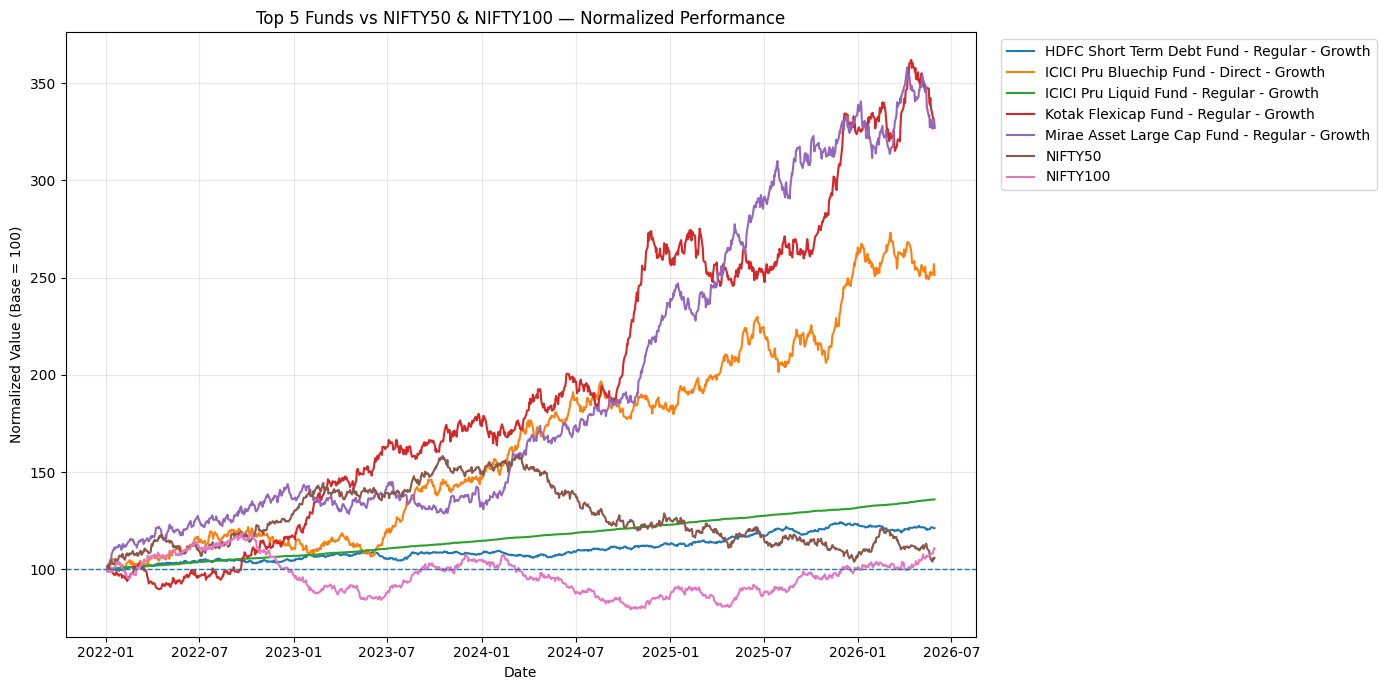

In [34]:
#Normalize Performance Chart
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

for col in all_series:
    plt.plot(
        normalized_data["date"],
        normalized_data[col],
        label=col
    )

plt.axhline(
    100,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100 — Normalized Performance"
)

plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "normalized_benchmark_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

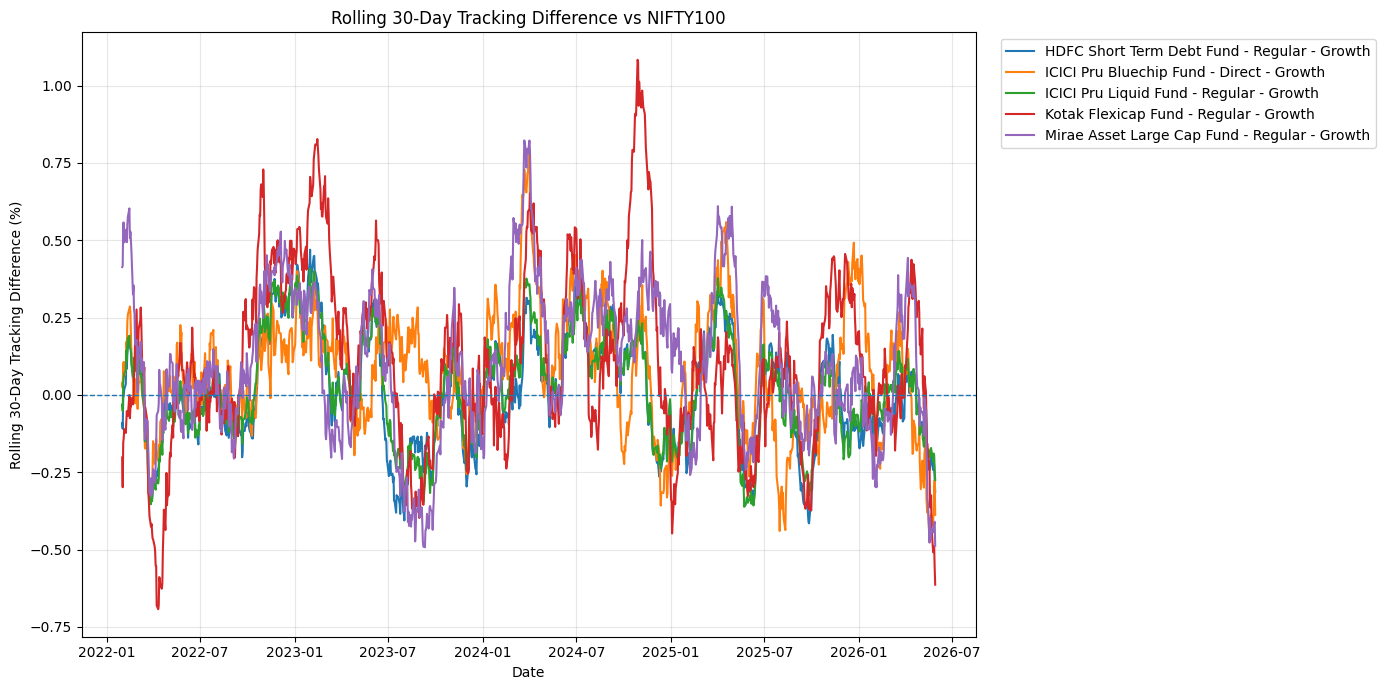

In [35]:
# ============================================================
# ROLLING 30-DAY TRACKING DIFFERENCE — NIFTY100
# ============================================================

plt.figure(figsize=(14, 7))

for fund in fund_columns:

    column = f"{fund}_vs_NIFTY100_30D"

    plt.plot(
        rolling_tracking_difference["date"],
        rolling_tracking_difference[column],
        label=fund
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Rolling 30-Day Tracking Difference vs NIFTY100"
)

plt.xlabel("Date")
plt.ylabel(
    "Rolling 30-Day Tracking Difference (%)"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "rolling_30d_tracking_difference_nifty100.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

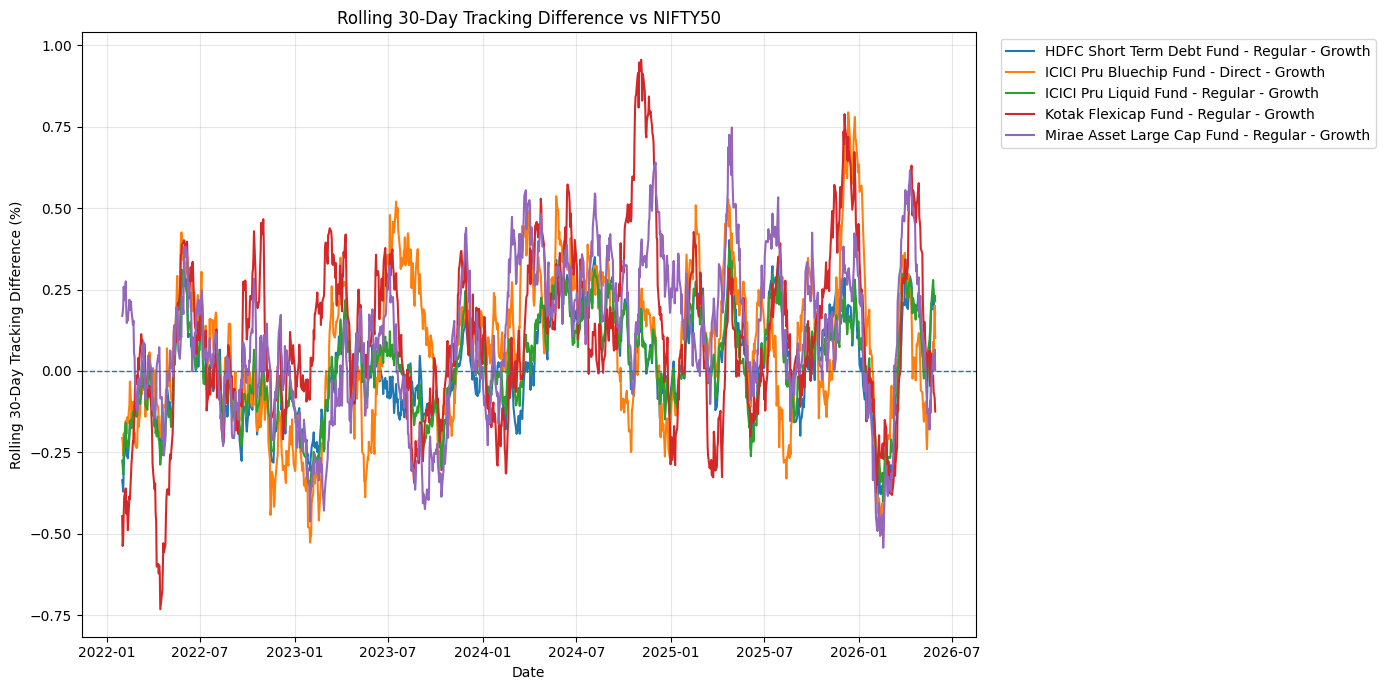

In [36]:
# ============================================================
# ROLLING 30-DAY TRACKING DIFFERENCE — NIFTY50
# ============================================================

plt.figure(figsize=(14, 7))

for fund in fund_columns:

    column = f"{fund}_vs_NIFTY50_30D"

    plt.plot(
        rolling_tracking_difference["date"],
        rolling_tracking_difference[column],
        label=fund
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Rolling 30-Day Tracking Difference vs NIFTY50"
)

plt.xlabel("Date")
plt.ylabel(
    "Rolling 30-Day Tracking Difference (%)"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "rolling_30d_tracking_difference_nifty50.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 📊 Benchmark Comparison & Tracking Analysis

## Objective

The objective of this analysis is to compare the performance of the Top 5 mutual fund schemes against the NIFTY50 and NIFTY100 benchmarks over the selected 3-year analysis period.

The analysis evaluates both cumulative performance and benchmark alignment using daily return-based metrics.

---

## Methodology

The analysis was performed using the following methodology:

1. Selected the Top 5 mutual fund schemes based on the calculated Fund Score.
2. Calculated daily mutual fund returns from NAV data.
3. Calculated daily NIFTY50 and NIFTY100 returns from benchmark index data.
4. Aligned fund and benchmark returns by trading date.
5. Normalized all series to a common base value of 100 for cumulative performance visualization.
6. Calculated annualized Tracking Error using daily active returns.
7. Calculated Rolling 30-Day Tracking Difference to identify periods of relative outperformance and underperformance.

### Tracking Error

Tracking Error measures the volatility of the difference between a fund's return and its benchmark return.

\[
TE = \sigma(R_{fund} - R_{benchmark}) \times \sqrt{252}
\]

where:

- \(R_{fund}\) = daily fund return
- \(R_{benchmark}\) = daily benchmark return
- 252 = approximate number of trading days in a year

Tracking Error was calculated separately against both NIFTY50 and NIFTY100.

---

## Normalized Performance Analysis

The normalized performance chart starts every fund and benchmark at a common value of 100.

This allows the cumulative growth trajectories of the Top 5 funds to be compared directly with the NIFTY50 and NIFTY100, independent of their original NAV or index levels.

### Interpretation

- A value above 100 represents cumulative growth from the starting point.
- A value below 100 represents a decline from the starting point.
- A steeper upward trajectory indicates stronger cumulative performance.
- The relative position of a fund against NIFTY50 and NIFTY100 indicates whether it generated stronger or weaker cumulative performance during the analysis period.

---

## Tracking Error Analysis

Tracking Error was calculated using daily return differences rather than normalized NAV values.

This approach is more appropriate for financial performance analysis because Tracking Error measures the volatility of active returns.

A lower Tracking Error indicates that the fund's daily return pattern is more closely aligned with the benchmark.

A higher Tracking Error indicates greater deviation from benchmark returns.

Tracking Error alone should not be interpreted as a measure of fund quality. A fund may have a high Tracking Error because it follows a different investment strategy and may simultaneously generate higher returns.

---

## Rolling 30-Day Tracking Difference

Rolling 30-Day Tracking Difference measures the average active return of each fund relative to its benchmark over a rolling 30-trading-day window.

### Interpretation

- Positive values indicate recent outperformance relative to the benchmark.
- Negative values indicate recent underperformance.
- Values close to zero indicate performance broadly aligned with the benchmark.

The rolling analysis helps identify periods where fund performance diverged materially from the benchmark.

---

## Key Analytical Considerations

The benchmark comparison should be interpreted together with CAGR, Sharpe Ratio, Alpha, Maximum Drawdown and Tracking Error.

A fund with high historical returns but high risk or large drawdowns may not necessarily represent the strongest risk-adjusted investment.

Similarly, a fund with low Tracking Error is not automatically superior; it simply indicates closer benchmark alignment.

Therefore, benchmark analysis provides an additional perspective alongside the overall Fund Scorecard.

---

## Conclusion

The benchmark analysis provides a comprehensive comparison of the Top 5 mutual fund schemes against NIFTY50 and NIFTY100.

By combining normalized cumulative performance, daily return-based Tracking Error and Rolling 30-Day Tracking Difference, the analysis evaluates both long-term performance and short-term benchmark deviation.

These metrics complement the Fund Scorecard and provide a more complete view of fund performance, risk and benchmark alignment.

In [37]:
display(performance_summary)

,Series,Start_Value,End_Value,Total_Return_pct
4,Mirae Asset Large Cap Fund - Regular - Growth,100.0,327.781083,227.781083
3,Kotak Flexicap Fund - Regular - Growth,100.0,327.047809,227.047809
1,ICICI Pru Bluechip Fund - Direct - Growth,100.0,251.267885,151.267885
2,ICICI Pru Liquid Fund - Regular - Growth,100.0,135.993389,35.993389
0,HDFC Short Term Debt Fund - Regular - Growth,100.0,121.155227,21.155227
6,NIFTY100,100.0,110.788751,10.788751
5,NIFTY50,100.0,105.858757,5.858757


In [38]:
display(tracking_error)

,amfi_code,scheme_name,Tracking_Error_NIFTY50_pct,Tracking_Error_NIFTY100_pct,Observations_NIFTY50,Observations_NIFTY100
0,120507,ICICI Pru Liquid Fund - Regular - Growth,12.891203,12.904358,1149,1149
1,100025,HDFC Short Term Debt Fund - Regular - Growth,13.644549,13.453514,1149,1149
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,19.137582,19.158700,1149,1149
3,148567,Mirae Asset Large Cap Fund - Regular - Growth,19.399579,18.966368,1149,1149
4,120843,Kotak Flexicap Fund - Regular - Growth,20.514777,20.642497,1149,1149


In [39]:
print("Highest CAGR:")
display(
    benchmark_summary.loc[
        benchmark_summary["CAGR_3Y_pct"].idxmax()
    ]
)

print("Lowest TE vs NIFTY50:")
display(
    tracking_error.loc[
        tracking_error["Tracking_Error_NIFTY50_pct"].idxmin()
    ]
)

print("Lowest TE vs NIFTY100:")
display(
    tracking_error.loc[
        tracking_error["Tracking_Error_NIFTY100_pct"].idxmin()
    ]
)

Highest CAGR:


Benchmark_Rank                                                             4
amfi_code                                                             148567
scheme_name                    Mirae Asset Large Cap Fund - Regular - Growth
CAGR_3Y_pct                                                        34.000916
Tracking_Error_NIFTY50_pct                                         19.399579
Tracking_Error_NIFTY100_pct                                        18.966368
Observations_NIFTY50                                                    1149
Observations_NIFTY100                                                   1149
Name: 3, dtype: object

Lowest TE vs NIFTY50:


amfi_code                                                        120507
scheme_name                    ICICI Pru Liquid Fund - Regular - Growth
Tracking_Error_NIFTY50_pct                                    12.891203
Tracking_Error_NIFTY100_pct                                   12.904358
Observations_NIFTY50                                               1149
Observations_NIFTY100                                              1149
Name: 0, dtype: object

Lowest TE vs NIFTY100:


amfi_code                                                        120507
scheme_name                    ICICI Pru Liquid Fund - Regular - Growth
Tracking_Error_NIFTY50_pct                                    12.891203
Tracking_Error_NIFTY100_pct                                   12.904358
Observations_NIFTY50                                               1149
Observations_NIFTY100                                              1149
Name: 0, dtype: object

In [ ]:
import pandas as pd

df = pd.read_csv(r"D:\mutual-fund-analysis\data\raw\fund_master.csv")

print("Fund Houses:")
print(df["fund_house"].unique())

print("\nCategories:")
print(df["category"].unique())

print("\nSub-Categories:")
print(df["sub_category"].unique())

print("\nRisk Grades:")
print(df["risk_grade"].unique())

In [8]:
print(df.columns.tolist())


['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [9]:
print("\nRisk Categories:")
print(df["risk_category"].unique())


Risk Categories:
['Moderate' 'Very High' 'Low' 'High' 'Moderately High']


In [11]:
import pandas as pd

fund = pd.read_csv(r"D:\mutual-fund-analysis\data\raw\fund_master.csv")
nav = pd.read_csv(r"D:\mutual-fund-analysis\data\processed\nav_history_cleaned.csv")

fund_codes = set(fund["amfi_code"])
nav_codes = set(nav["amfi_code"])

missing = fund_codes - nav_codes

print("Fund master AMFI codes:", len(fund_codes))
print("NAV history AMFI codes:", len(nav_codes))
print("Missing AMFI codes:", len(missing))

if len(missing) == 0:
    print("✅ All fund_master AMFI codes exist in nav_history.")
else:
    print("Missing codes:")
    print(missing)

Fund master AMFI codes: 40
NAV history AMFI codes: 40
Missing AMFI codes: 0
✅ All fund_master AMFI codes exist in nav_history.


In [12]:
import pandas as pd

nav = pd.read_csv(r"D:\mutual-fund-analysis\data\processed\nav_history_cleaned.csv")

print("Shape:", nav.shape)
print("\nMissing values:")
print(nav.isna().sum())

print("\nDuplicate rows:", nav.duplicated().sum())

print("\nNAV <= 0:", (nav["nav"] <= 0).sum())

print("\nUnique AMFI codes:", nav["amfi_code"].nunique())

print("\nDate range:")
print(nav["date"].min(), "to", nav["date"].max())

Shape: (46000, 3)

Missing values:
amfi_code    0
date         0
nav          0
dtype: int64

Duplicate rows: 0

NAV <= 0: 0

Unique AMFI codes: 40

Date range:
2022-01-03 to 2026-05-29
